<a href="https://colab.research.google.com/github/shubhiv02-learner/banking-log-anomaly-detection/blob/main/notebooks/SentinelIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SentinelIQ – Banking Anomaly Detection & Observability Platform

## Project Overview

SentinelIQ is a hybrid statistical and machine learning–driven anomaly detection framework designed for operational banking telemetry and observability monitoring.

The project combines:

* statistical anomaly detection techniques,
* rolling-window operational intelligence,
* and unsupervised machine learning models

to identify abnormal system behavior, operational incidents, and anomalous telemetry patterns in simulated banking environments.

The framework was developed to evaluate how different anomaly detection methodologies behave under realistic operational telemetry conditions using both raw and engineered feature spaces.

---

# Key Features

## Statistical Intelligence Layer

* Rolling window aggregation
* EWMA-based trend monitoring
* CUSUM drift detection
* Statistical anomaly indicators
* Incident probability estimation


---

## Machine Learning Anomaly Detection

Implemented unsupervised anomaly detection models:

* Isolation Forest
* One-Class SVM
* Local Outlier Factor (LOF)

---

## Ensemble Detection Framework

* Weighted ensemble anomaly scoring
* Combined model anomaly ranking
* Percentile-based threshold analysis
* Adaptive anomaly prioritization

---

# Experimental Methodologies

The framework evaluates anomaly detection performance across multiple feature-engineering strategies:

1. Raw Operational Telemetry
2. Raw Data + Rolling Window Aggregation
3. Raw Data + Statistical Features + Rolling Aggregation
4. Weighted Ensemble Scoring

---

# Key Findings

* Isolation Forest consistently delivered the strongest and most stable performance across all experiments.
* Raw operational telemetry preserved anomaly separability effectively.
* Rolling-window aggregation improved temporal anomaly intelligence.
* One-Class SVM improved anomaly sensitivity but generated higher false positives.
* Local Outlier Factor performed poorly within transformed rolling statistical feature spaces.
* Weighted ensemble scoring improved anomaly coverage and operational sensitivity.

---

# Technology Stack

* Python
* Google Colab
* Pandas
* NumPy
* Scikit-learn
* Matplotlib
* Seaborn

---

# Current Project Status

## Implemented

* Statistical anomaly framework
* Rolling-window feature engineering
* Unsupervised ML anomaly detection
* Ensemble anomaly scoring
* Comparative model evaluation

## In Progress

* ROC and Precision-Recall visualizations
* Anomaly timeline visualization
* Threshold optimization
* Benchmarking framework

## Planned Enhancements

* Autoencoder-based anomaly detection
* Multi-layer anomaly intelligence architecture
* Dynamic risk scoring
* Real-time streaming detection
* Production observability dashboard

---

# Conclusion

SentinelIQ demonstrates how hybrid statistical and machine learning techniques can be combined to build an operationally meaningful anomaly detection framework for banking telemetry environments.

The project highlights the importance of:

* feature engineering,
* model-specific behavior analysis,
* rolling temporal intelligence,
* and ensemble-based anomaly prioritization

when designing real-world observability and anomaly monitoring systems.


In [ ]:
# Install reportlab for PDF generation
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.1 MB/s eta 0:00:00


# **Stage 1 - Load libraries and generate synthetic data**

In [1]:
# ============================================================
# SentinelIQ V 0.2
# Statistical Observability Platform
# ============================================================

# This project simulates a banking observability pipeline
# capable of detecting infrastructure anomalies before
# they affect critical financial systems.
#
# Core Techniques Used:
# - EWMA Drift Detection
# - CUSUM Anomaly Detection
# - Persistence Scoring
# - Correlation Analysis
# - Bayesian Incident Prioritization
#
# Author: Shubhi Verma
# Environment: Google Colab / Jupyter Notebook
# ============================================================


# =========================
# STEP 1 — IMPORT LIBRARIES
# =========================

# Pandas -> Data manipulation
# NumPy -> Numerical operations
# PyPlot -> Dashboard visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import warnings
import os
import io

warnings.filterwarnings("ignore")
folders = [
    "src",
    "scripts",
    "data/raw",
    "data/processed",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


In [ ]:
%%writefile scripts/generate_banking_logs.py

# ============================================================
# SentinelIQ V0.2
# Banking Log Generator
# ============================================================

# This script generates realistic structured banking logs
# for anomaly detection and observability experiments.
#
# Simulated Banking Services:
# - payment-api
# - auth-service
# - trading-engine
# - fraud-detection
# - notification-service
#
# Simulated Events:
# - normal requests
# - latency spikes
# - API timeouts
# - database failures
# - queue lag
# - infrastructure saturation
#
# Output:
# data/banking_logs.json
# data/banking_logs.csv
# ============================================================


# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import random
import json
import os
from datetime import datetime, timedelta
import io # Added this import


# =========================
# CREATE OUTPUT DIRECTORY
# =========================

os.makedirs("outputs", exist_ok=True)


# ============================================================
# CONFIGURATION
# ============================================================

TOTAL_LOGS = 15000

START_TIME = datetime(2026, 1, 1)

SERVICES = [
    "payment-api",
    "auth-service",
    "trading-engine",
    "fraud-detection",
    "notification-service",
    "portfolio-service",
    "investment-engine"
]

ENDPOINTS = [
    "/login",
    "/transfer",
    "/payment",
    "/trade",
    "/portfolio",
    "/kyc",
    "/withdrawal"
]

# Map services to their specific endpoints
SERVICE_ENDPOINTS_MAP = {
    "payment-api": ["/payment", "/transfer", "/withdrawal"],
    "auth-service": ["/login", "/kyc"],
    "trading-engine": ["/trade", "/payment", "/transfer"],
    "fraud-detection": ["/kyc", "/payment", "/transfer"],
    "notification-service": ["/login", "/transfer", "/payment"],
    "portfolio-service": ["/portfolio", "/trade"],
    "investment-engine": ["/trade", "/portfolio", "/withdrawal"]
}

# Map services to their base latencies
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}

REGIONS = [
    "India",
    "Singapore",
    "USA",
    "Germany",
    "UAE"
]

STATUS_TYPES = [
    "success",
    "timeout",
    "db_failure",
    "high_latency",
    "queue_delay"
]

# ANOMALY CONFIGURATION: Inject anomalies in three specific windows
ANOMALY_WINDOWS = [
    (int(TOTAL_LOGS * 0.1), int(TOTAL_LOGS * 0.12)), # 10-12% of logs
    (int(TOTAL_LOGS * 0.4), int(TOTAL_LOGS * 0.42)), # 40-42% of logs
    (int(TOTAL_LOGS * 0.7), int(TOTAL_LOGS * 0.72))  # 70-72% of logs
]
ANOMALY_PROB_IN_WINDOW = 0.8  # High probability of anomaly within a window
ANOMALY_PROB_OUT_WINDOW = 0.001 # Low probability of anomaly outside a window

# Define anomaly types and their weights to achieve the desired distribution
anomaly_types_for_selection = ["timeout", "db_failure", "high_latency", "queue_delay"]
anomaly_weights_for_selection = [0.03, 0.01, 0.4, 0.56] # 4% critical, 96% medium

# ============================================================
# GENERATE SINGLE LOG EVENT
# ============================================================

def generate_log_event(index):

    """
    Generates one structured banking log event.

    Simulates:
    - infrastructure metrics
    - service health
    - latency behavior
    - operational failures
    """

    # --------------------------------------------------------
    # Generate timestamp
    # --------------------------------------------------------

    timestamp = START_TIME + timedelta(
        seconds=index * 30
    )

    # --------------------------------------------------------
    # Randomly select banking service and its associated endpoint
    # --------------------------------------------------------

    service = random.choice(SERVICES)
    possible_endpoints = SERVICE_ENDPOINTS_MAP.get(service, ENDPOINTS) # Default to all endpoints if service not in map
    endpoint = random.choice(possible_endpoints)

    region = random.choice(REGIONS)

    # --------------------------------------------------------
    # Generate normal operational metrics with service-specific latency
    # --------------------------------------------------------

    base_latency = SERVICE_LATENCY_MAP.get(service, 120) # Default to 120 if service not in map
    latency_ms = int(
        np.random.normal(base_latency, 20) # Randomize around the base_latency
    )
    cpu_usage = round(np.random.normal(55, 8),2)
    memory_usage = round(np.random.normal(60, 10),2)
    queue_lag = max(0,int(np.random.normal(5, 2)))
    error_code = None
    status = "success"
    severity = "low"
    error_count = 0 # Initialize error_count
    is_anomaly = 0 # Initialize is_anomaly
    # --------------------------------------------------------
    # Inject anomalies probabilistically based on defined windows
    # --------------------------------------------------------

    in_anomaly_window = False
    for start, end in ANOMALY_WINDOWS:
        if start <= index <= end:
            in_anomaly_window = True
            break

    anomaly_roll = random.random()

    # Determine anomaly probability based on whether the current index is in an anomaly window
    current_anomaly_probability = ANOMALY_PROB_IN_WINDOW if in_anomaly_window else ANOMALY_PROB_OUT_WINDOW

    if anomaly_roll < current_anomaly_probability:
        is_anomaly = 1
        # Select anomaly type based on defined weights
        anomaly_type = random.choices(anomaly_types_for_selection, weights=anomaly_weights_for_selection, k=1)[0]

        # =========================================
        # TIMEOUT EVENT
        # =========================================

        if anomaly_type == "timeout":

            latency_ms =max(base_latency+10,int(np.random.normal(base_latency, 100))) # Randomize around the base_latency
            cpu_usage += random.randint(10, 30)
            queue_lag += random.randint(10, 40)
            error_code = "TIMEOUT_ERROR"
            status = "timeout"
            severity = "critical"
            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # DATABASE FAILURE
        # =========================================

        elif anomaly_type == "db_failure":

            latency_ms =max(base_latency+10,int(np.random.normal(base_latency, 80))) # Randomize around the base_latency
            cpu_usage += random.randint(5, 20)
            memory_usage += random.randint(10, 20)
            error_code = "DB_CONNECTION_FAILURE"
            status = "db_failure"
            severity = "critical"
            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # HIGH LATENCY EVENT
        # =========================================

        elif anomaly_type == "high_latency":
            latency_ms =max(base_latency+30,int(np.random.normal(base_latency, 80))) # Randomize around the base_latency
            queue_lag += random.randint(5, 15)
            error_code = "LATENCY_SPIKE"
            status = "high_latency"
            severity = "medium"
            error_count = random.randint(2, 5) # Assign a numerical error count

        # =========================================
        # QUEUE DELAY EVENT
        # =========================================

        elif anomaly_type == "queue_delay":

            latency_ms =max(base_latency+20,int(np.random.normal(base_latency, 50))) # Randomize around the base_latenc
            queue_lag += random.randint(20, 60)
            error_code = "QUEUE_BACKPRESSURE"
            status = "queue_delay"
            severity = "medium"
            error_count = random.randint(2, 5) # Assign a numerical error count

    # --------------------------------------------------------
    # Create structured log event
    # --------------------------------------------------------
    latency_ms = abs(latency_ms)

    log_event = {

        "timestamp": timestamp.isoformat(),
        "service": service,
        "endpoint": endpoint,
        "region": region,
        "latency_ms": latency_ms,
        "cpu_usage": round(cpu_usage, 2),
        "memory_usage": round(memory_usage, 2),
        "queue_lag": queue_lag,
        "status": status,
        "error_code": error_code,
        "severity": severity,
        "error_count": error_count, # Add error_count to the log event
         "is_anomaly": is_anomaly # Add is_anamoly to the log event
    }

    return log_event


# ============================================================
# GENERATE COMPLETE DATASET
# ============================================================

def generate_banking_logs(total_logs):

    """
    Generates complete banking observability dataset.
    """

    logs = []

    for i in range(total_logs):

        log = generate_log_event(i)

        logs.append(log)

    return logs


# ============================================================
# SAVE LOGS
# ============================================================

def save_logs(logs):

    """
    Saves logs in:
    - JSON format
    - CSV format
    """

    # --------------------------------------------------------
    # Save JSON logs
    # --------------------------------------------------------

    with open(
        "data/banking_logs.json",
        "w"
    ) as f:

        json.dump(
            logs,
            f,
            indent=4
        )

    # --------------------------------------------------------
    # Save CSV logs
    # --------------------------------------------------------

    df = pd.DataFrame(logs)

    df.to_csv(
        "data/banking_logs.csv",
        index=False
    )

    # Capture the statistics output string
    stats_string = display_statistics(df)

    # Define the output file path
    output_file_path = 'outputs/logsStatistics.txt'

    # Ensure the 'outputs' directory exists
    os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

    # Write the captured output to the file
    with open(output_file_path, 'w') as f:
        f.write(stats_string)

    print(f"Log statistics saved to '{output_file_path}'") # Print confirmation here

    return df


# ============================================================
# DISPLAY SAMPLE STATISTICS
# ============================================================

def display_statistics(df):

    """
    Displays dataset overview and anomaly distribution.
    Returns the statistics as a string.
    """
    output_string = io.StringIO()

    output_string.write("\n================================================")
    output_string.write("\n SENTINELIQ LOG GENERATION COMPLETED ")
    output_string.write("\n================================================\n")
    output_string.write(f"\nTotal Logs Generated : {len(df)}\n")
    output_string.write("\nServices Monitored:")
    output_string.write(df['service'].value_counts().to_string())
    output_string.write("\n\nStatus Distribution:")
    output_string.write(df['status'].value_counts().to_string())
    output_string.write("\n\nSeverity Distribution:")
    output_string.write(df['severity'].value_counts().to_string())
    output_string.write("\n\nSample Logs:")
    output_string.write(df.head().to_string())

    # Print to stdout as well for immediate display
    print(output_string.getvalue())
    print("printed sample logs")
    return output_string.getvalue()


# ============================================================
# MAIN DATA GENERATION EXECUTION PIPELINE
# ============================================================

def main():

    print("\nGenerating banking observability logs...\n")

    logs = generate_banking_logs(TOTAL_LOGS)

    df = save_logs(logs)


    print("\nFiles Saved:\n")
    print(f"Banking logs in json saved to outputs/banking_logs.json ")
    print(f"Banking logs in csv format saved to outputs/banking_logs.csv ")
    print(f"Log statistics saved to outputs/logsStatistics.txt")
    print("\nLog generation completed successfully.\n")
    return df

Writing scripts/generate_banking_logs.py


In [ ]:
%%writefile scripts/call_generate_banking_logs.py
import generate_banking_logs

if __name__ == "__main__":
    df = generate_banking_logs.main()
    print(df.head())


Writing scripts/call_generate_banking_logs.py


In [ ]:
! python scripts/call_generate_banking_logs.py


Generating banking observability logs...


 SENTINELIQ LOG GENERATION COMPLETED 

Total Logs Generated : 15000

Services Monitored:service
payment-api             2206
fraud-detection         2168
trading-engine          2154
portfolio-service       2145
notification-service    2133
investment-engine       2109
auth-service            2085

Status Distribution:status
success         14286
queue_delay       406
high_latency      275
timeout            25
db_failure          8

Severity Distribution:severity
low         14286
medium        681
critical       33

Sample Logs:             timestamp            service    endpoint     region  latency_ms  cpu_usage  memory_usage  queue_lag   status error_code severity  error_count  is_anomaly
0  2026-01-01T00:00:00    fraud-detection    /payment  Singapore         202      70.22         67.42          7  success       None      low            0           0
1  2026-01-01T00:00:30  investment-engine  /portfolio        USA         160      45.2

In [ ]:
%%writefile src/generate_banking_logs_metrics.py
import pandas as pd
import numpy as np

SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}
# ============================================================
# STEP 3 — EWMA DRIFT DETECTION
# ============================================================

def apply_ewma_detection(df, alpha=0.3):

    """
    Applies EWMA anomaly detection.

    EWMA helps detect gradual operational drift
    before systems cross critical thresholds.

    Parameters:
    -----------
    df : pandas.DataFrame
        Banking observability dataset

    alpha : float
        EWMA smoothing factor
        typically between 0 and 1, which dictates how quickly the average adapts to new data
        Higher the value it reacts faster to recent changes

    Returns:
    --------
    df : pandas.DataFrame
        Updated dataframe with EWMA metrics

    threshold : float
        Dynamic anomaly threshold
    """
    # Compute EWMA latency trend based on raw latency_ms (for plotting compatibility)
    df['ewma_latency'] = (round(df['latency_ms'].ewm(alpha=alpha).mean(),2))

    # Dynamic anomaly threshold for raw latency (for dashboard plotting purposes)
    raw_latency_plot_threshold = (df['ewma_latency'].mean()+ 2*df['ewma_latency'].std())

    # Calculate expected base latency for each service
    df['expected_base_latency'] = df['service'].map(SERVICE_LATENCY_MAP)

    # Calculate latency deviation from the expected base latency
    df['latency_deviation'] = df['latency_ms'] - df['expected_base_latency']
    df['latency_deviation'] = df['latency_deviation'].abs()
    # Compute EWMA latency deviation trend for actual anomaly detection
    df['ewma_latency_deviation_for_alert'] = (round(df['latency_deviation'].ewm(alpha=alpha).mean(),2))

    # Dynamic anomaly threshold based on deviation for alerting
    # The mean of ewma_latency_deviation_for_alert should ideally be close to 0 if the system is stable.
    deviation_alert_threshold = (
        df['ewma_latency_deviation_for_alert'].abs().mean()+2 * df['ewma_latency_deviation_for_alert'].std()
        )
    print(f"Raw Latency Plot Threshold (for dashboard): {raw_latency_plot_threshold}")
    print(f"Deviation Alert Threshold (for detection): {deviation_alert_threshold}")
    # Flag anomalous drift regions based on deviation
    df['ewma_alert'] = (
        (df['ewma_latency_deviation_for_alert'].abs() > deviation_alert_threshold)
    )

    print("EWMA detection completed.\n")
    print(f"Raw Latency Plot Threshold (for dashboard): {raw_latency_plot_threshold}")
    print(f"Deviation Alert Threshold (for detection): {deviation_alert_threshold}")
    return df, raw_latency_plot_threshold # Return the threshold for raw latency for dashboard compatibility


# ============================================================
# STEP 4 — CUSUM DETECTION
# ============================================================

def apply_cusum_detection(df):

    """
    Applies CUSUM detection.

    CUSUM identifies cumulative deviations
    from normal operational behavior.

    Useful for:
    - silent degradation
    - queue accumulation
    - sustained instability
    """
    # Ensure latency_deviation is available (compute if not already)
    if 'latency_deviation' not in df.columns:
        df['expected_base_latency'] = df['service'].map(SERVICE_LATENCY_MAP)
        df['latency_deviation'] = df['latency_ms'] - df['expected_base_latency']


    mu = df['latency_ms'].std()
    k = mu * 0.5
    print(f"CUSUM Smoothing Factor (k): {k}")
    h = mu*5 #ideally should be 5 or 6
    print(f"CUSUM Alert Threshold (for detection): {h}")

    # Target for deviation
    target = 0 # Ideally should be 0

    cusum_values = []
    current_cusum_sum = 0.0 # Initialize cumulative sum for each day
    # Convert timestamp to datetime if not already (good for plotting)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['logdate'] = df['timestamp'].dt.date # Add logdate column

    if not df.empty:
        prev_date = df['timestamp'].iloc[0].date()
    else:
        print("DataFrame is empty, cannot apply CUSUM detection.")
        return df

    for i in range(len(df)):
        current_date = df['logdate'].iloc[i]
        latency_dev = df['latency_deviation'].iloc[i]

        if current_date != prev_date:
            # Date has changed, reset the CUSUM sum for the new day
            current_cusum_sum = 0.0
            prev_date = current_date


        # Calculate CUSUM for the current point
        current_cusum_sum = round(max(0.0, current_cusum_sum + (latency_dev - target - k)), 2)
        cusum_values.append(current_cusum_sum)

    df['cusum'] = cusum_values

    # Alert threshold
    df['cusum_alert'] = (df['cusum'] > h)

    print("CUSUM detection completed.\n")

    return df


# ============================================================
# STEP 5 — PERSISTENCE SCORING
# ============================================================

def calculate_persistence_score(df):

    """
    Measures anomaly persistence duration.
    Persistent anomalies are treated as
    higher operational risks than isolated spikes.
    """

    # Combine anomaly signals
    df['combined_alert'] = ( df['ewma_alert'] | df['cusum_alert'])

    persistence = []
    count = 0

    for val in df['combined_alert']:
        if val:
            count += 1
        else:
            count = 0

        persistence.append(count)

    df['persistence_score'] = persistence
    print("Persistence scoring completed.\n")

    return df


# ==================================
# STEP 6 — CORRELATION ANALYSIS
# ==================================

def generate_correlation_analysis(df):

    correlation = df[
        [
            'latency_deviation',
            'error_count',
            'cpu_usage',
            'ewma_latency_deviation_for_alert',
            'cusum',
            'persistence_score',
            'incident_probability'
        ]
    ].corr().round(2)

    print("\nCorrelation Matrix:\n")

    custom_labels = ['Latency', 'Errors',  'CPU','EWMA','CUSUM','PS','IP']
    correlation.columns = custom_labels
    correlation.index = custom_labels
    print(correlation)
    print('\n\n')
    return correlation


# ============================================
# STEP 7 — BAYESIAN PRIORITIZATION
# ============================================

def apply_bayesian_prioritization(df):
    import pandas
    df['incident_probability'] = (round(

        0.4 * (df['persistence_score'] / df['persistence_score'].max())
        +
        0.3 * (df['error_count']/df['error_count'].max())
        +
        0.3 * (df['cpu_usage']/df['cpu_usage'].max()), 2)
    )

    df['priority'] = pandas.cut(df['incident_probability'], bins=[0, 0.3, 0.5, 0.7,1],
        labels=['Low','Medium','High','Critical'])

    df['priority'] = df['priority'].astype(str)
    return df

Writing src/generate_banking_logs_metrics.py


In [ ]:
%%writefile src/generate_analysis.py
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}
# ==================================
# STEP 8 — EXECUTIVE DASHBOARD
# ==================================

def generate_dashboard(df, threshold):
    import matplotlib.pyplot as pyplot
    import pandas as pd # Import pandas here for to_datetime

    # Convert timestamp to datetime if not already (good for plotting)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Plot the latency data
    pyplot.figure(figsize=(14,6))

    pyplot.plot(
        df['timestamp'],
        df['latency_deviation'],
        label='Adjusted Latency per service'
    )

    pyplot.plot(
        df['timestamp'],
        df['ewma_latency_deviation_for_alert'],
        label='EWMA'
    )

    critical_df = df[df['priority'] == 'Critical']
    high_df = df[df['priority'] == 'High']

    # Plot critical priority as scatter points on the latency axis
    pyplot.scatter(
        critical_df['timestamp'],
        critical_df['latency_deviation'], # Plot latency at critical priority
        color='purple',
        marker='X', # Use 'X' marker for critical priority
        s=100, # Size of the marker
        label='Critical Priority'
    )

    pyplot.axhline(
        threshold,
        color='red',
        linestyle='--',
        label='Threshold'
    )

    pyplot.title(
        "SentinelIQ Banking System Monitoring"
    )

    pyplot.xlabel("Timestamp")

    pyplot.ylabel("Adjusted Latency per service(ms)")

    pyplot.legend()

    pyplot.grid(True)

    pyplot.xticks(rotation=45)

    pyplot.savefig("outputs/latency_chart.png")

    pyplot.show()


# ==================================
# STEP 9 — EXECUTIVE SUMMARY
# ==================================

def generate_executive_summary(df):

    critical_count = (
        df['priority'] == 'Critical').sum()

    high_count = (
        df['priority'] == 'High').sum()
    medium_count = (
        df['priority'] == 'Medium').sum()


    summary = f"""

    SENTINELIQ OPERATIONAL SUMMARY
    --------------------------------
    Total Incidents : {len(df)}
    Critical Incidents : {critical_count}
    High Incidents   : {high_count}
    Medioum Incidents   : {medium_count}


    OBSERVATIONS
    ------------

    - Sustained latency degradation detected
    - Infrastructure pressure increasing
    - Multiple correlated anomaly windows identified

    Recommended Action:

    -----------------
    Investigate payment processing systems
    and infrastructure resource utilization.

    """
    print(summary)

    return summary


def write_pdf_report(file_path, content):
    from reportlab.platypus import SimpleDocTemplate
    from reportlab.lib.pagesizes import letter

    pdf = SimpleDocTemplate(
        file_path,
        pagesize=letter,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=30
    )
    pdf.build(content)
    print(f"PDF generated successfully: {file_path}")

def generate_executive_summary_report(df):
    from reportlab.platypus import (Paragraph, Spacer, Image)
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib import colors
    from reportlab.platypus.flowables import HRFlowable

    # ============================================================
    # PDF REPORT GENERATION
    # ============================================================

    pdf_file = "outputs/banking_anomaly_report.pdf"

    styles = getSampleStyleSheet()
    content = []

    # ============================================================
    # TITLE
    # ============================================================

    content.append(Paragraph(
        "<b>SentinelIQ Banking Anomaly Detection Report</b>",
        styles['Title']
    ))

    content.append(Spacer(1, 20))

    # ============================================================
    # EXECUTIVE SUMMARY
    # ============================================================

    content.append(Paragraph(
        "<b>Executive Summary</b>",
        styles['Heading1']
    ))

    Total_count = len(df)
    critical_count = ( df['priority'] == 'Critical').sum()
    high_count = ( df['priority'] == 'High').sum()
    medium_count = ( df['priority'] == 'Medium').sum()

    content.append(Paragraph(
        "<b>SENTINELIQ OPERATIONAL SUMMARY</b>",
        styles['Heading2']
    ))
    summary = f"""

    \n\n

    Total Incidents : {Total_count}\n
    Critical Incidents : {critical_count}\n
    High Incidents   : {high_count}\n
    Medium Incidents   : {medium_count}\n\n

    """
    executive_summary_text = """
    This report provides an overview of simulated banking logs,
    observed anomalies, service failures, and system health metrics.

    Key findings include:

    • Increased authentication failures during peak traffic.
    • Elevated fraud detection alerts from payment-api.
    • Trading-engine latency spikes observed intermittently.
    • Isolation Forest identified suspicious transaction patterns.

    Overall system stability remained acceptable, though multiple
    high-severity anomalies require operational review.
    """
    summary = summary + executive_summary_text
    print(summary)
    content.append(Paragraph(summary, styles['BodyText']))

    content.append(Spacer(1, 15))

    # Horizontal line
    content.append(HRFlowable(width="100%", color=colors.grey))
    content.append(Spacer(1, 15))

    # ============================================================
    # PNG IMAGE / CHART
    # ============================================================

    content.append(Paragraph(
        "<b>Anomaly Trend Visualization</b>",
        styles['Heading2']
    ))

    # PNG image path
    image_path = "outputs/latency_chart.png"

    # Add image
    img = Image(image_path, width=450, height=250)
    content.append(img)

    content.append(Spacer(1, 20))

    # ============================================================
    # SAMPLE TABLE (Commented out in original, keeping it that way)
    # ============================================================

    content.append(Paragraph(
        "<b>Service Error Summary</b>",
        styles['Heading2']
    ))
    """
    # Example table data
    service_data = [
        ["Service", "Error Count", "Severity"],
        ["payment-api", "42", "High"],
        ["auth-service", "31", "Medium"],
        ["fraud-detection", "15", "Critical"],
        ["trading-engine", "22", "High"]
    ]

    # Create table
    service_table = Table(service_data, colWidths=[180, 120, 120])

    # Table styling
    service_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 10),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
    ]))

    content.append(service_table)

    content.append(Spacer(1, 25))
    """
    # ============================================================
    # ADDITIONAL INSIGHTS
    # ============================================================

    content.append(Paragraph(
        "<b>Observations</b>",
        styles['Heading1']
    ))

    observations = """
    The anomaly distribution indicates that most failures originated
    from authentication and payment processing systems.

    The fraud-detection service generated fewer events but showed
    higher severity anomalies.

    Further monitoring and alert correlation is recommended.
    """

    content.append(Paragraph(observations, styles['BodyText']))

    # ============================================================
    # BUILD PDF
    # ============================================================
    write_pdf_report(pdf_file, content)

    return

Writing src/generate_analysis.py


In [ ]:
%%writefile src/run_logs.py
import pandas as pd
import json

import generate_banking_logs_metrics as banking_utils
import generate_analysis as analysis_utils

# Load the banking_logs.csv file into a DataFrame
df = pd.read_csv('data/banking_logs.csv')

print("Loaded 'data/banking_logs.csv' into 'df'.")

# Display the first 5 rows of the DataFrame
print(df.head())

print("Applying EWMA Detection...\n")
df, threshold = banking_utils.apply_ewma_detection(df)

print("Applying CUSUM Detection...\n")
df = banking_utils.apply_cusum_detection(df)

print("Calculating Persistence Scores...\n")
df = banking_utils.calculate_persistence_score(df)

print("Applying Bayesian Prioritization...\n")
df = banking_utils.apply_bayesian_prioritization(df)

print("Running Correlation Analysis...\n")
correlation = banking_utils.generate_correlation_analysis(df)

# Display the first 5 rows of the DataFrame after metrics updation
print(df.head())

print("Generating Monitoring Dashboard...\n")
analysis_utils.generate_dashboard(df, threshold)

print("Generating Executive Summary...\n")
summary = analysis_utils.generate_executive_summary(df)
analysis_utils.generate_executive_summary_report(df)

# Save outputs
df.to_csv("outputs/sentineliq_results.csv",index=False )
print("Output with metrics saved to outputs/sentineliq_results.csv ")

with open('outputs/executive_summary.txt', 'w') as f:
      f.write(summary)
print("Executive summary saved to 'outputs/executive_summary.txt'")

print("\nPipeline Execution Completed.\n")

Writing src/run_logs.py


In [ ]:
! python src/run_logs.py

Loaded 'data/banking_logs.csv' into 'df'.
             timestamp            service  ... error_count is_anomaly
0  2026-01-01T00:00:00    fraud-detection  ...           0          0
1  2026-01-01T00:00:30  investment-engine  ...           0          0
2  2026-01-01T00:01:00    fraud-detection  ...           0          0
3  2026-01-01T00:01:30        payment-api  ...           0          0
4  2026-01-01T00:02:00  portfolio-service  ...           0          0

[5 rows x 13 columns]
Applying EWMA Detection...

Raw Latency Plot Threshold (for dashboard): 165.53320105301935
Deviation Alert Threshold (for detection): 32.091610594785294
EWMA detection completed.

Raw Latency Plot Threshold (for dashboard): 165.53320105301935
Deviation Alert Threshold (for detection): 32.091610594785294
Applying CUSUM Detection...

CUSUM Smoothing Factor (k): 23.351089434560354
CUSUM Alert Threshold (for detection): 233.51089434560353
CUSUM detection completed.

Calculating Persistence Scores...

Persistence s

# Stage 2
Load data and do pre processing

In [ ]:
import pandas as pd

df = pd.read_csv('outputs/sentineliq_results.csv')

print("Loaded 'outputs/sentineliq_results.csv' into 'results_df'.")
print(df.head())
count = df.duplicated().sum()
print(f'duplicate rows {count}')
print(df.info())

print(df.describe().T)

Loaded 'outputs/sentineliq_results.csv' into 'results_df'.
             timestamp            service    endpoint     region  latency_ms  \
0  2026-01-01 00:00:00    fraud-detection    /payment  Singapore         202   
1  2026-01-01 00:00:30  investment-engine  /portfolio        USA         160   
2  2026-01-01 00:01:00    fraud-detection        /kyc    Germany         196   
3  2026-01-01 00:01:30        payment-api   /transfer      India         139   
4  2026-01-01 00:02:00  portfolio-service  /portfolio        UAE         122   

   cpu_usage  memory_usage  queue_lag   status error_code  ...  \
0      70.22         67.42          7  success        NaN  ...   
1      45.25        101.09          6  success        NaN  ...   
2      52.80         55.56          4  success        NaN  ...   
3      64.44         63.88          4  success        NaN  ...   
4      57.28         65.25          6  success        NaN  ...   

  latency_deviation  ewma_latency_deviation_for_alert  ewma_ale

In [ ]:
desc = pd.DataFrame(index = list(df)) #create Rows with columns of orginal dataframe
desc['type'] = df.dtypes
desc['count'] = df.count()
desc['nunique'] = df.nunique()
desc['%unique'] = desc['nunique'] /len(df) * 100
desc['null'] = df.isnull().sum()
desc['%null'] = desc['null'] / len(df) * 100
desc = pd.concat([desc,df.describe().T.drop('count',axis=1)],axis=1)
desc.sort_values(by=['type','null']).style.background_gradient(cmap='YlOrBr')\
    .bar(subset=['mean'],color='green')\
    .bar(subset=['max'],color='red')\
    .bar(subset=['min'], color='pink').to_excel("outputs/Sentinel_preprocess.xlsx")

In [ ]:
# Get a list of categorical columns in the dataframe
categorical_columns = df.select_dtypes(include=['object']).columns

# Check the unique values and their counts for each categorical column
for col in categorical_columns:
    print(f"Column: {col}")
    print("-" * 25)
    print(f"Unique values: {df[col].nunique()}")
    print(f"Unique values sample: {df[col].unique()[:10]}")  # Display a sample of unique values
    print("-" * 50)

Column: timestamp
-------------------------
Unique values: 15000
Unique values sample: ['2026-01-01 00:00:00' '2026-01-01 00:00:30' '2026-01-01 00:01:00'
 '2026-01-01 00:01:30' '2026-01-01 00:02:00' '2026-01-01 00:02:30'
 '2026-01-01 00:03:00' '2026-01-01 00:03:30' '2026-01-01 00:04:00'
 '2026-01-01 00:04:30']
--------------------------------------------------
Column: service
-------------------------
Unique values: 7
Unique values sample: ['fraud-detection' 'investment-engine' 'payment-api' 'portfolio-service'
 'notification-service' 'trading-engine' 'auth-service']
--------------------------------------------------
Column: endpoint
-------------------------
Unique values: 7
Unique values sample: ['/payment' '/portfolio' '/kyc' '/transfer' '/trade' '/login'
 '/withdrawal']
--------------------------------------------------
Column: region
-------------------------
Unique values: 5
Unique values sample: ['Singapore' 'USA' 'Germany' 'India' 'UAE']
----------------------------------------

### [Stage 3 EDA]

No numerical column is Null

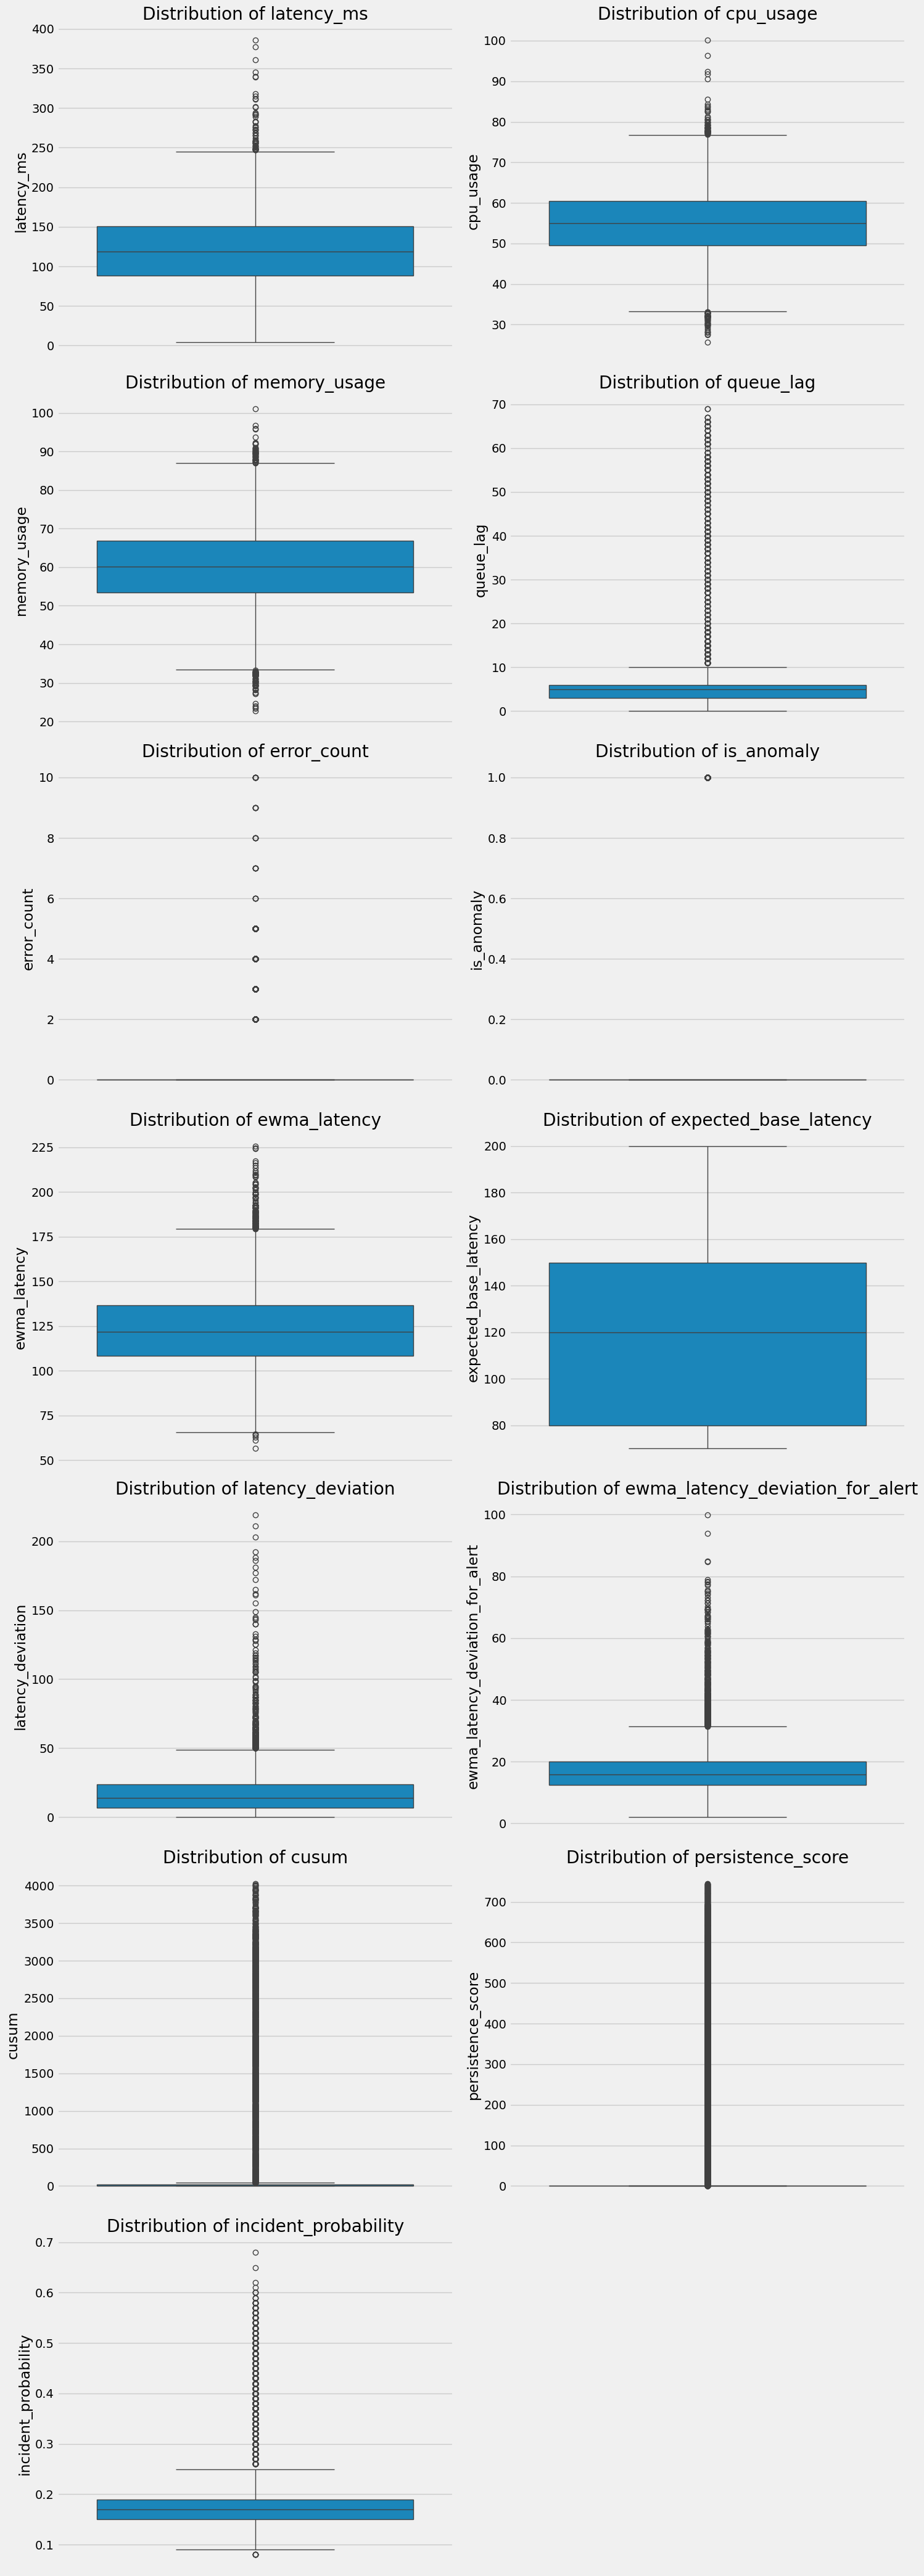

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for all plots in this cell
plt.style.use("fivethirtyeight")

# Assume numerical_columns is defined from a previous cell. If not, re-define it here:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns for the subplots
num_cols_for_plot = 2 # Number of charts per row
num_rows_for_plot = (len(numerical_columns) + num_cols_for_plot - 1) // num_cols_for_plot

fig, axes = plt.subplots(num_rows_for_plot, num_cols_for_plot, figsize=(15, 6 * num_rows_for_plot))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_columns):
    # Create the boxplot vertically on the current subplot
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel(col) # Set y-label as it's a vertical boxplot

# Hide any unused subplots if the number of numerical columns is not a perfect multiple of num_cols_for_plot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

# Save the entire figure
plt.savefig("outputs/box_plots_all_numerical.png", bbox_inches="tight")
plt.close() # Closes the plot window to save memory

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression


### KDE Plot for Incident Probability with Thresholds

This plot visualizes the distribution of the `incident_probability` column. Regions where the probability is above 0.5 are highlighted in red, and regions above 0.6 are further highlighted in purple, allowing for quick identification of higher-risk probability ranges.

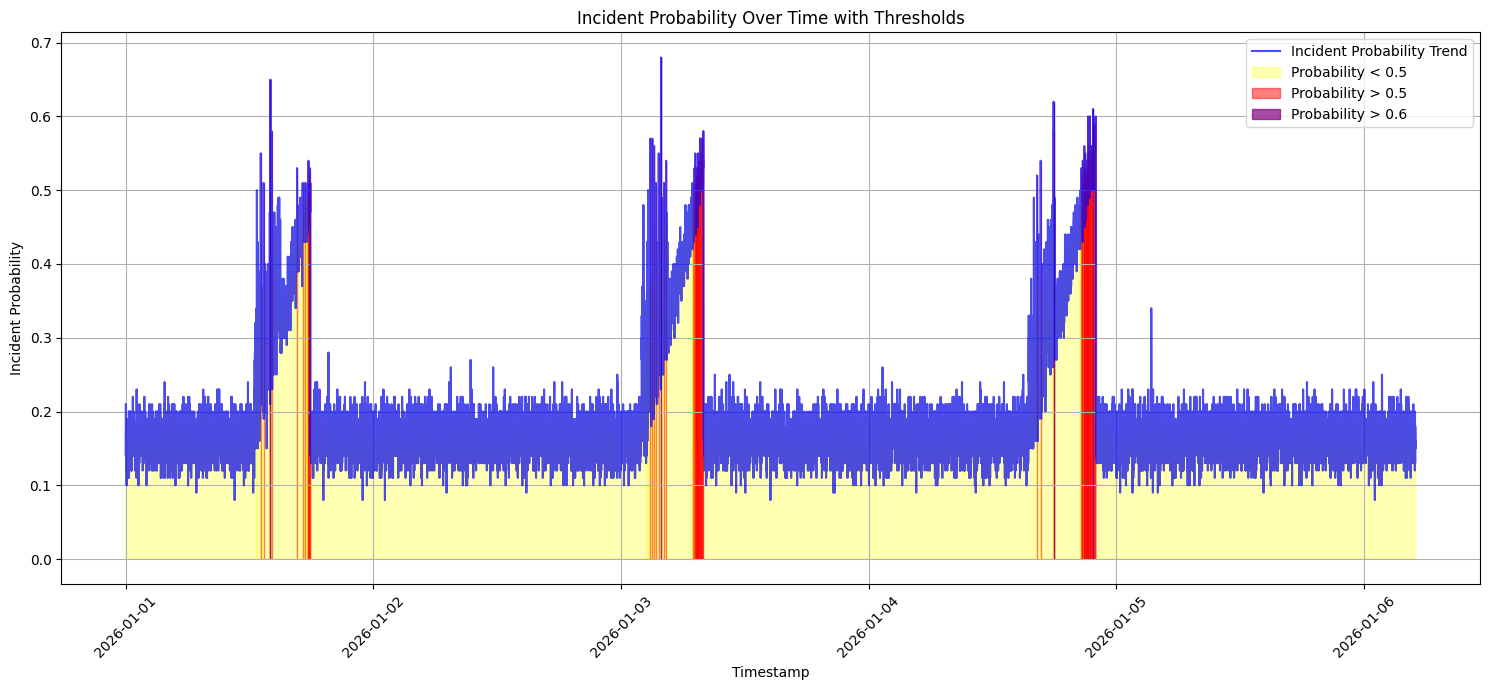

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure timestamp is in datetime format for plotting
df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.figure(figsize=(15, 7))

# Plot the incident probability over time
plt.plot(df['timestamp'], df['incident_probability'], color='blue', label='Incident Probability Trend', alpha=0.7)

# Get data for fill_between
x_values = df['timestamp']
y_values = df['incident_probability']

# Fill the area for incident_probability < 0.5 (yellow)
plt.fill_between(x_values, y_values, where=(y_values < 0.5), color='yellow', alpha=0.3, label='Probability < 0.5')

# Fill the area for incident_probability > 0.5 (red)
plt.fill_between(x_values, y_values, where=(y_values > 0.5), color='red', alpha=0.5, label='Probability > 0.5')

# Fill the area for incident_probability > 0.6 (purple). This will overlap the red in that region.
plt.fill_between(x_values, y_values, where=(y_values > 0.6), color='purple', alpha=0.7, label='Probability > 0.6')

plt.title('Incident Probability Over Time with Thresholds')
plt.xlabel('Timestamp')
plt.ylabel('Incident Probability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig("outputs/incident_probability_time_series.png", bbox_inches="tight")
plt.close() # Close the plot to free up memory

In [ ]:
# For categorical columns, we'll fill missing values with the mode (most frequent category)
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(categorical_columns)

Index(['service', 'endpoint', 'region', 'status', 'error_code', 'severity',
       'logdate', 'priority'],
      dtype='object')


EDA for categorical columns

In [ ]:
"""
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Extract new features from 'timestamp'
df['Transaction_Date'] = df['timestamp'].dt.date
df['Transaction_Time'] = df['timestamp'].dt.time
df['Transaction_Day'] = df['timestamp'].dt.day
df['Transaction_Month'] = df['timestamp'].dt.month
#df['Transaction_Month_Name'] = df['timestamp'].dt.strftime('%b')
df['Transaction_Year'] = df['timestamp'].dt.year
df['Transaction_Hour'] = df['timestamp'].dt.hour
df['Transaction_Minute'] = df['timestamp'].dt.minute
df['Transaction_Second'] = df['timestamp'].dt.second
"""

"\ndf['timestamp'] = pd.to_datetime(df['timestamp'])\n# Extract new features from 'timestamp'\ndf['Transaction_Date'] = df['timestamp'].dt.date\ndf['Transaction_Time'] = df['timestamp'].dt.time\ndf['Transaction_Day'] = df['timestamp'].dt.day\ndf['Transaction_Month'] = df['timestamp'].dt.month\n#df['Transaction_Month_Name'] = df['timestamp'].dt.strftime('%b')\ndf['Transaction_Year'] = df['timestamp'].dt.year\ndf['Transaction_Hour'] = df['timestamp'].dt.hour\ndf['Transaction_Minute'] = df['timestamp'].dt.minute\ndf['Transaction_Second'] = df['timestamp'].dt.second\n"

In [ ]:
df['logdate'] = pd.to_datetime(df['timestamp']).dt.date
unique_dates = df['logdate'].unique()
print("Unique Transaction Dates:")
for date in unique_dates:
    print(date)

Unique Transaction Dates:
2026-01-01
2026-01-02
2026-01-03
2026-01-04
2026-01-05
2026-01-06


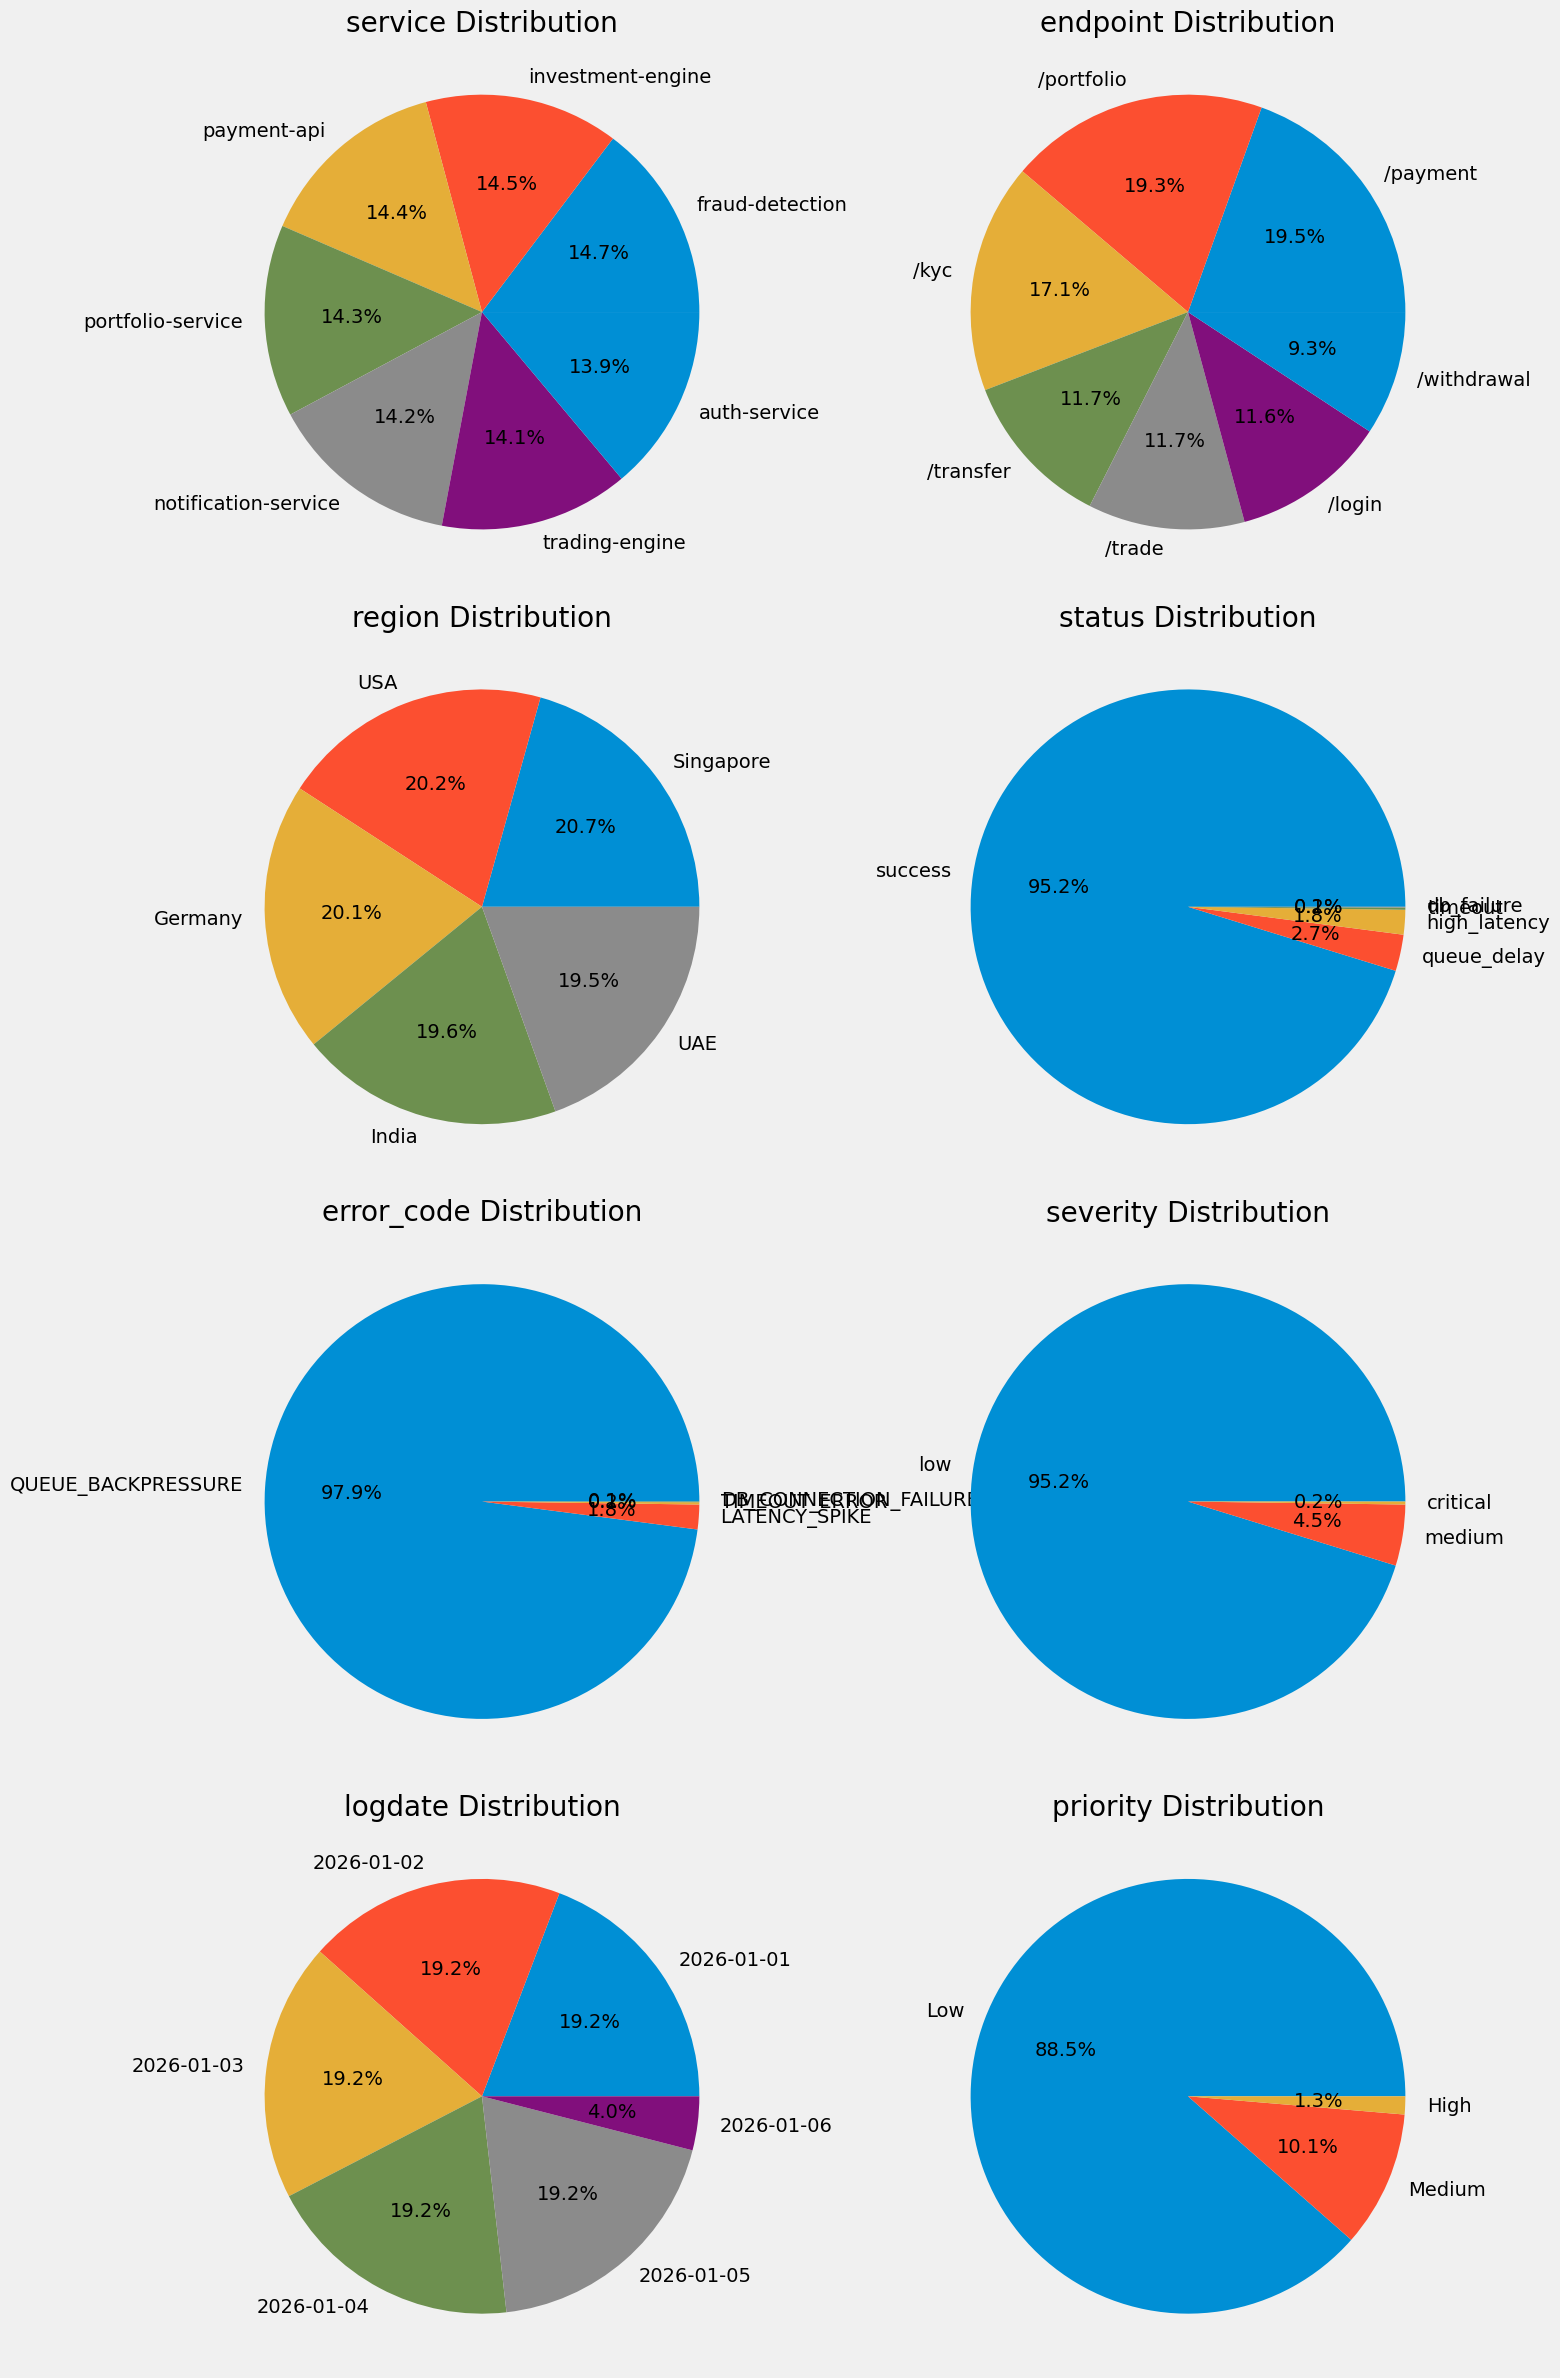

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter categorical columns to include only those with less than 10 unique values
# These are the columns we will actually plot.
plot_categorical_columns = [col for col in categorical_columns if df[col].nunique() < 10]

# Calculate the number of rows needed based on the number of charts to plot
num_cols = 2  # Number of charts per row
num_rows = (len(plot_categorical_columns) + num_cols - 1) // num_cols  # Dynamically calculate rows

# Create the figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 6))  # Adjust figure size for more rows

# Flatten the axes array for easier iteration, handling the case of a single row or column
axes = axes.flatten()

for ax_index, col in enumerate(plot_categorical_columns):
    # Plot on the respective subplot
    ax = axes[ax_index]
    ax.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%')
    ax.set_title(f'{col} Distribution')

# Hide any unused subplots (in case there are fewer than `num_rows * num_cols` charts)
for i in range(len(plot_categorical_columns), len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

Encode Categorical Features

In [ ]:
# Initializing the LabelEncoder
#Preprocessing data before machine learning, To map text strings to integers like Red- 0, Blue - 1

label_encoder = LabelEncoder()

In [ ]:
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.head()

,timestamp,service,endpoint,region,latency_ms,cpu_usage,memory_usage,queue_lag,status,error_code,...,latency_deviation,ewma_latency_deviation_for_alert,ewma_alert,logdate,cusum,cusum_alert,combined_alert,persistence_score,incident_probability,priority
0,2026-01-01 00:00:00,1,2,2,202,70.22,67.42,7,3,2,...,2,2.00,False,0,0.00,False,False,0,0.21,1
1,2026-01-01 00:00:30,2,3,4,160,45.25,101.09,6,3,2,...,30,18.47,False,0,6.65,False,False,0,0.14,1
2,2026-01-01 00:01:00,1,0,0,196,52.80,55.56,4,3,2,...,4,11.86,False,0,0.00,False,False,0,0.16,1
3,2026-01-01 00:01:30,4,5,1,139,64.44,63.88,4,3,2,...,11,11.52,False,0,0.00,False,False,0,0.19,1
4,2026-01-01 00:02:00,5,3,3,122,57.28,65.25,6,3,2,...,2,8.09,False,0,0.00,False,False,0,0.17,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   timestamp                         15000 non-null  datetime64[ns]
 1   service                           15000 non-null  int64         
 2   endpoint                          15000 non-null  int64         
 3   region                            15000 non-null  int64         
 4   latency_ms                        15000 non-null  int64         
 5   cpu_usage                         15000 non-null  float64       
 6   memory_usage                      15000 non-null  float64       
 7   queue_lag                         15000 non-null  int64         
 8   status                            15000 non-null  int64         
 9   error_code                        15000 non-null  int64         
 10  severity                          15000 non-nu

In [ ]:
df.nunique()

,0
timestamp,15000
service,7
endpoint,7
region,5
latency_ms,276
cpu_usage,3553
memory_usage,4210
queue_lag,69
status,5
error_code,4


Stage 6 EDA after Label Encoder

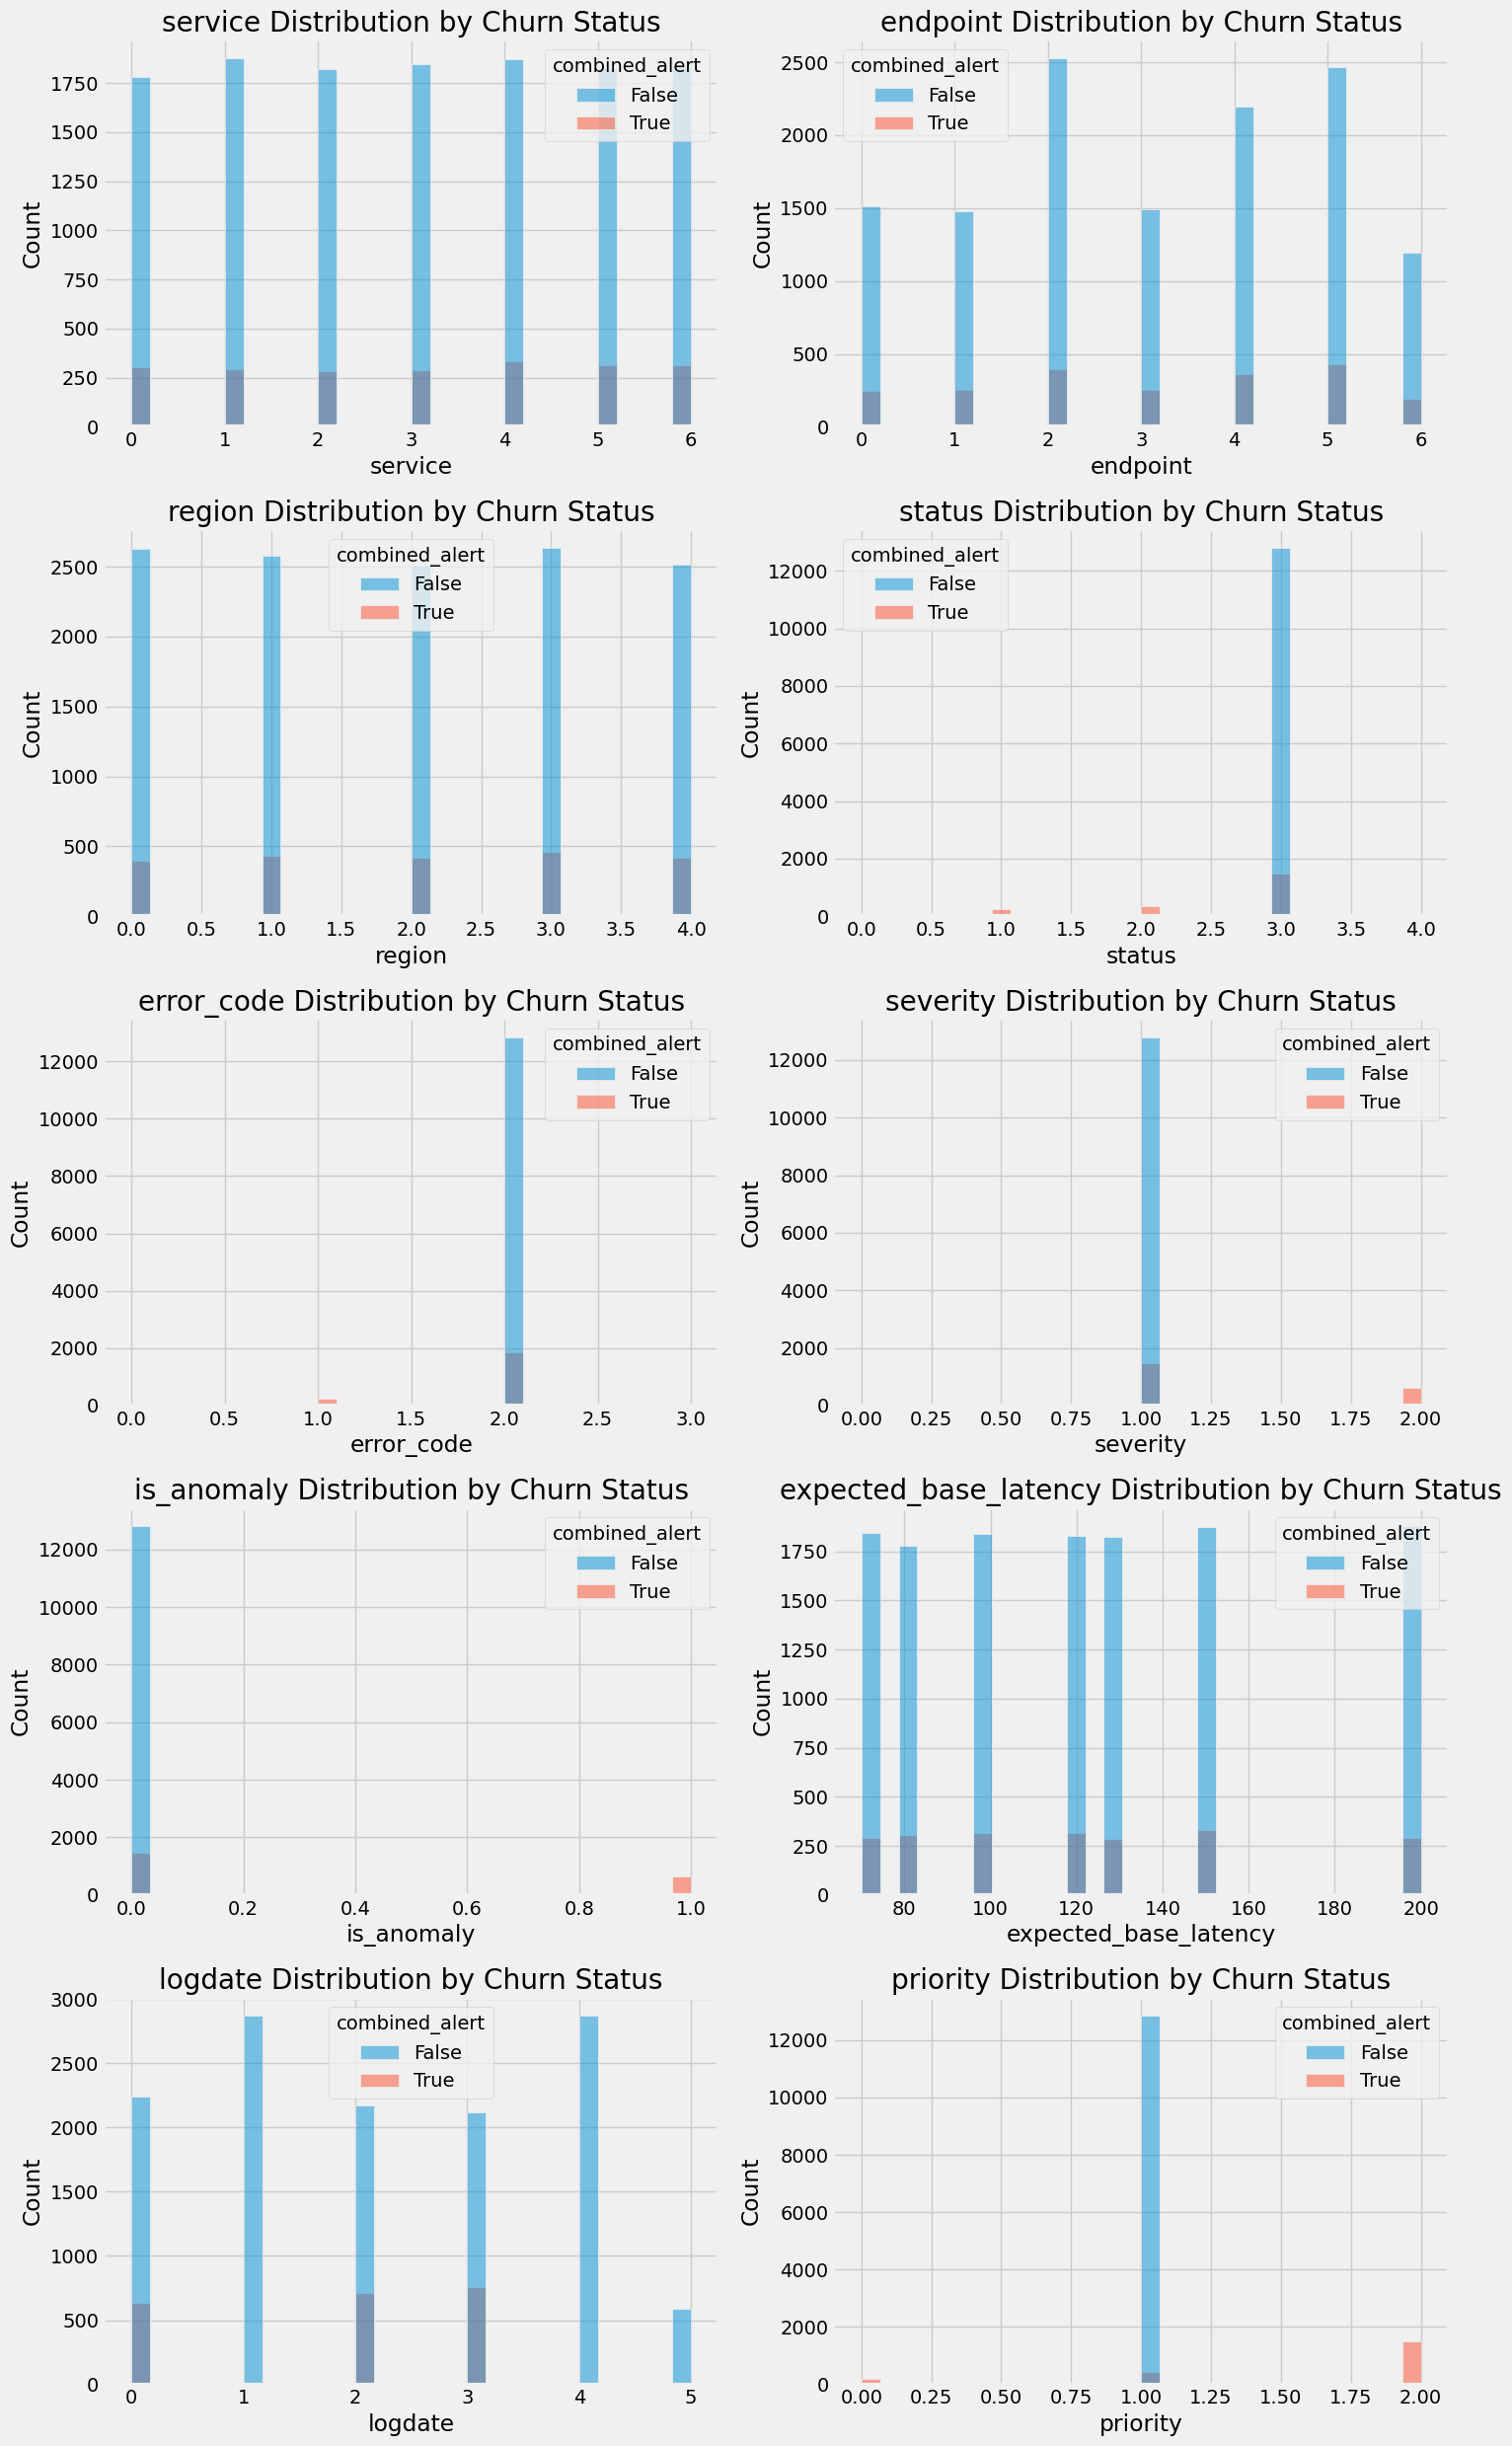

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter numerical columns with less than 10 unique values
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
numerical_features = [col for col in numerical_features if df[col].nunique() < 10]

# Set the number of charts per row
num_cols = 2  # Number of charts per row

# Calculate the number of rows needed based on the number of features
num_rows = (len(numerical_features) + num_cols - 1) // num_cols  # This ensures enough rows are created

# Create a figure with the appropriate number of rows and columns
plt.figure(figsize=(15, 5 * num_rows))

# Plot the histograms for the filtered numerical columns
for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(data=df, x=feature, hue='combined_alert', bins=30)
    plt.title(f'{feature} Distribution by Churn Status')

plt.tight_layout()
plt.show()

# **Stage 7 - Visualize Fraud Patterns and Distribution of Features**

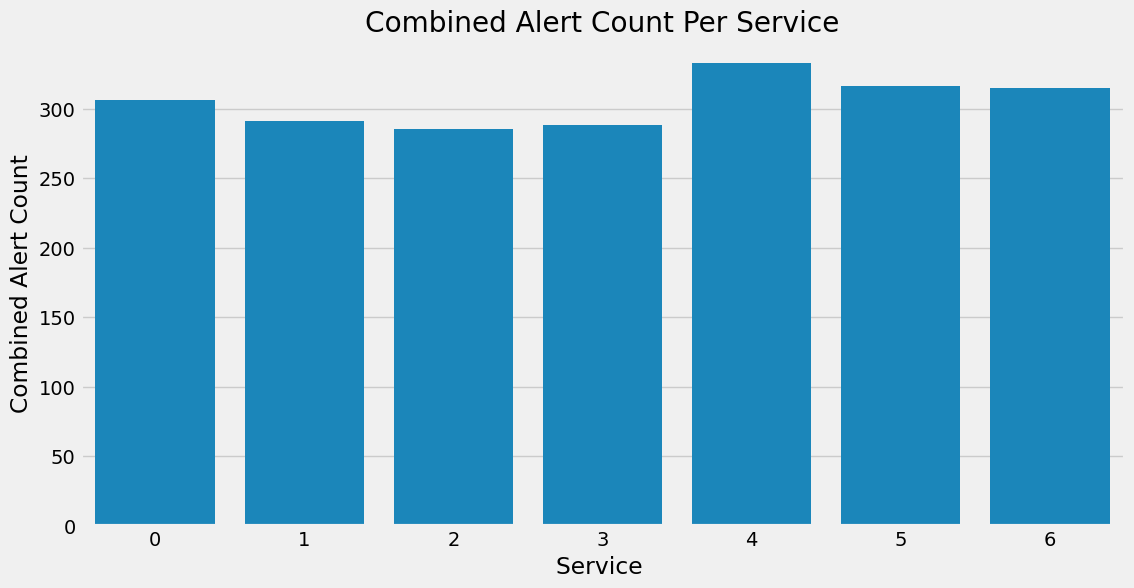

In [ ]:
#Visualize Alert Vs Service
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
alert_counts_per_service = df.groupby('service')['combined_alert'].sum().reset_index()
sns.barplot(data=alert_counts_per_service, x='service', y='combined_alert')
plt.title("Combined Alert Count Per Service")
plt.xlabel("Service ")
plt.ylabel("Combined Alert Count")
plt.show()

# Stage 8 - Plot Correlation Matrix to Understand Feature Relationships

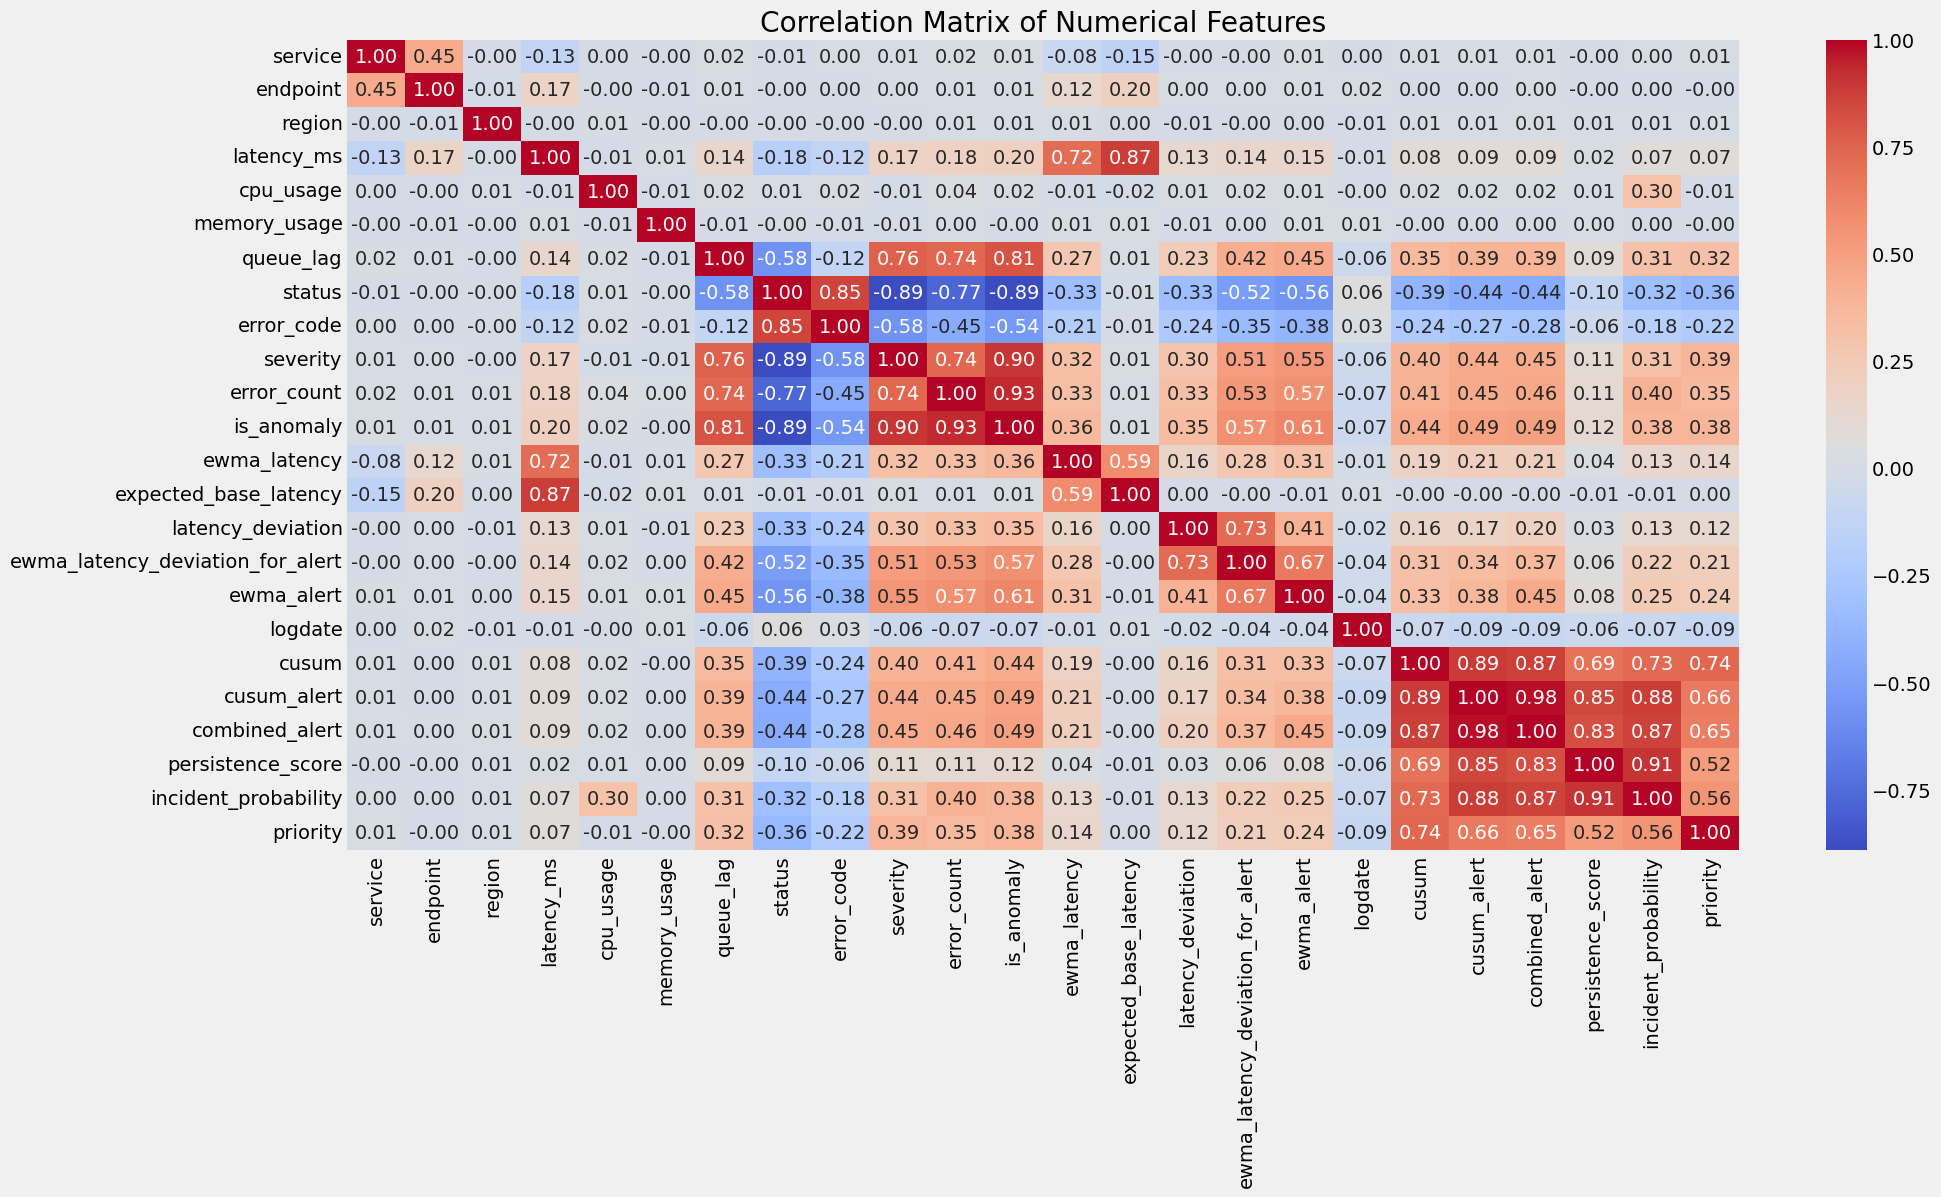

In [ ]:
plt.figure(figsize=(20, 10))

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number', 'bool'])

# Exclude any other non-numeric columns that might have slipped through (like encoded datetime objects if not handled)
# For instance, 'timestamp' was converted to int64 by LabelEncoder, but original datetime objects are not numerical.
# Let's ensure that any columns that are clearly not meant for correlation are excluded.
# Based on df.info(), the original timestamp, Transaction_Date, Transaction_Time columns are either object or int64 after encoding.
# If 'timestamp' was label encoded, it becomes int64, which is technically numeric but semantically not for correlation.
# So, let's explicitly drop it if it's there, along with the extracted date/time features.

# If 'timestamp' was label encoded to int64, it might still not be meaningful for correlation. Let's drop it explicitly.
columns_to_exclude = ['timestamp', 'Transaction_Date', 'Transaction_Time']
for col in columns_to_exclude:
    if col in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=[col])

correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()
plt.savefig("outputs/correlation_matrix.png")
plt.close()

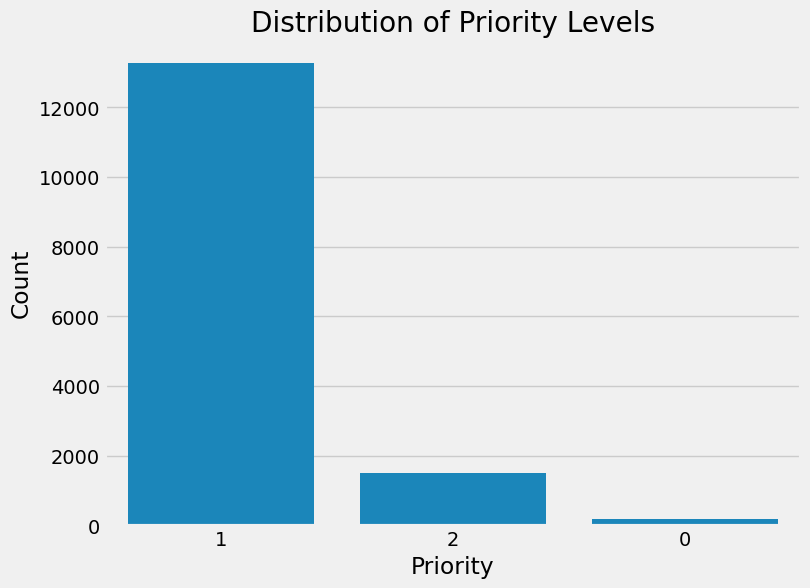

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='priority', data=df, order=df['priority'].value_counts().index)
plt.title('Distribution of Priority Levels')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.show()
plt.savefig('outputs/priority_distribution.png')
plt.close()

# **Stage 9 : Applying Isolation Forest for Anomaly Detection (Raw Data, no statistical features included)**

This section applies the Isolation Forest algorithm, an unsupervised learning method, to detect anomalies in the banking logs. Isolation Forest works by isolating anomalies rather than profiling normal data points, which makes it efficient and effective for high-dimensional datasets. The model will identify data points that are 'different' from the majority, flagging them as potential anomalies.

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

print("Applying Isolation Forest Detection...\n")

# Define numerical features for Isolation Forest
# Exclude 'timestamp' and other non-numerical or target-related columns
features_for_isolation_forest = df[[
    "service", "latency_ms", "cpu_usage",
    "queue_lag", "error_count"
]].copy()

# 2. Build a Pipeline combining the RobustScaler and Isolation Forest
# This automatically scales the data right before passing it to the model
iso_forest_pipeline = make_pipeline(
    RobustScaler(), IsolationForest(contamination=0.05, random_state=42)
)

# 3. Fit the pipeline and predict anomalies
# Isolation Forest returns: 1 for normal data, -1 for outliers
df["anomaly_score"] = iso_forest_pipeline.fit_predict(features_for_isolation_forest)

print("Isolation Forest detection completed.")

# The commented section used different feature selection and was already structured
# for direct use. I will now integrate the prediction result.
# The 'predictions' variable is not used in the pipeline approach, so I will remove the old commented block.

# Add Isolation Forest anomaly predictions to the DataFrame
# 'anomaly_score' from pipeline already has 1 for normal and -1 for outlier
df['ml_anomaly'] = df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)

# Save outputs
df.to_csv("outputs/sentineliq_results_ml_isofor.csv",index=False )

print("Output with metrics saved to outputs/sentineliq_results_ml_isofor.csv ")

print("Isolation Forest detection completed.\n")

Applying Isolation Forest Detection...

Isolation Forest detection completed.
Output with metrics saved to outputs/sentineliq_results_ml_isofor.csv 
Isolation Forest detection completed.



**Inspecting Isolation Forest Results**

Let's examine the first few rows of the DataFrame with the new ml_anomaly column and get a count of the detected anomalies. This will give us an initial idea of how many data points the Isolation Forest algorithm has identified as anomalous.


In [ ]:
#print(df[['timestamp', 'latency_ms', 'cpu_usage', 'memory_usage', 'queue_lag', 'ml_anomaly']].head())
print(f"Total anomalies detected by Isolation Forest: {df['ml_anomaly'].sum()}")



Total anomalies detected by Isolation Forest: 750


### Isolation Forest Model Evaluation

Now that we have applied the Isolation Forest, let's evaluate its performance using key classification metrics. We will compare the model's predictions (`ml_anomaly`) against the true anomaly labels (`is_anomaly`) present in the dataset.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Prepare true labels and predicted labels
y_true = df['is_anomaly']
y_pred = df['ml_anomaly']

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred))

# Calculate ROC AUC score if both classes are present
if len(y_true.unique()) > 1:
    roc_auc = roc_auc_score(y_true, y_pred)
    print(f"\n--- ROC AUC Score: {roc_auc:.4f} ---")
else:
    print("\nROC AUC Score cannot be calculated as only one class is present in y_true.")


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14286
           1       0.93      0.98      0.96       714

    accuracy                           1.00     15000
   macro avg       0.97      0.99      0.98     15000
weighted avg       1.00      1.00      1.00     15000


--- Confusion Matrix ---
[[14237    49]
 [   13   701]]

--- ROC AUC Score: 0.9892 ---


# Metric	Meaning
Precision	- Of detected anomalies, how many were truly anomalous

Recall- How many true anomalies were found

F1-score- Balance of precision + recall

ROC-AUC	- Ranking quality

Confusion Matrix -	TP, FP, FN, TN

Model working pretty well with given performance

--- Classification Report ---Contamination 0.25
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     14276
           1       0.19      1.00      0.32       724

    accuracy                           0.80     15000
   macro avg       0.60      0.89      0.60     15000
weighted avg       0.96      0.80      0.85     15000


--- Confusion Matrix ---
[[11250  3026]
 [    0   724]]

--- ROC AUC Score: 0.8940 ---

--- Classification Report ---(Contamination : 0.15)
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     14276
           1       0.32      1.00      0.49       724

    accuracy                           0.90     15000
   macro avg       0.66      0.95      0.72     15000
weighted avg       0.97      0.90      0.92     15000


--- Confusion Matrix ---
[[12750  1526]
 [    0   724]]

--- ROC AUC Score: 0.9466 ---


--- Classification Report ---(Contamination: 0.05)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14276
           1       0.94      0.98      0.96       724

    accuracy                           1.00     15000
   macro avg       0.97      0.99      0.98     15000
weighted avg       1.00      1.00      1.00     15000


--- Confusion Matrix ---
[[14232    44]
 [   18   706]]

--- ROC AUC Score: 0.9860 ---


In [ ]:

df.sort_values("anomaly_score").head(500)

,timestamp,service,endpoint,region,latency_ms,cpu_usage,memory_usage,queue_lag,status,error_code,...,ewma_alert,logdate,cusum,cusum_alert,combined_alert,persistence_score,incident_probability,priority,anomaly_score,ml_anomaly
1509,2026-01-01 12:34:30,3,2,4,100,53.37,65.80,32,2,2,...,False,0,45.50,False,False,0,0.28,1,-1,1
1508,2026-01-01 12:34:00,0,1,0,111,58.68,66.16,54,2,2,...,False,0,38.85,False,False,0,0.30,1,-1,1
1507,2026-01-01 12:33:30,6,5,3,130,54.17,64.70,19,1,1,...,False,0,31.20,False,False,0,0.31,2,-1,1
1506,2026-01-01 12:33:00,5,3,1,150,41.31,74.40,10,1,1,...,False,0,24.55,False,False,0,0.21,1,-1,1
1504,2026-01-01 12:32:00,3,2,3,90,55.57,55.41,67,2,2,...,False,0,28.25,False,False,0,0.32,2,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6003,2026-01-03 02:01:30,6,5,4,141,63.99,69.22,44,2,2,...,True,2,66.95,False,True,1,0.28,1,-1,1
1797,2026-01-01 14:58:30,0,0,1,100,48.71,68.32,55,2,2,...,False,0,3141.70,True,True,269,0.38,2,-1,1
1796,2026-01-01 14:58:00,3,1,0,100,56.14,50.42,21,1,1,...,False,0,3145.05,True,True,268,0.46,2,-1,1
1795,2026-01-01 14:57:30,0,0,3,118,48.89,51.39,63,2,2,...,False,0,3138.40,True,True,267,0.44,2,-1,1


# **Stage 10 : Comparing models on Rolling Window**

**Step** 1: Window-Based Feature Engineering

**Load Libraries**

In [58]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [54]:
Data_Config = {
    "window_size": "5min",
    "traindata": 0.8
}
ENSEMBLE_CONFIG = {

    "weights": {
        "IsolationForest": 0.8,
        "LOF": 0.0,
        "OneClassSVM": 0.2
    },

    "threshold": 0.7
}

print(f"Ensemble Weights: {ENSEMBLE_CONFIG['weights']}")
print(f"Ensemble Threshold: {ENSEMBLE_CONFIG['threshold']}")
print(f"IsolationForest Weight: {ENSEMBLE_CONFIG['weights']['IsolationForest']}")

Ensemble Weights: {'IsolationForest': 0.8, 'LOF': 0.0, 'OneClassSVM': 0.2}
Ensemble Threshold: 0.7
IsolationForest Weight: 0.8


**1. Creating 5 min rolling window and aggregate raw data**

In [55]:
df = pd.read_csv("outputs/sentineliq_results.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

window_df = (
    df.set_index("timestamp")
      .resample(Data_Config["window_size"])
      .agg({
          "latency_ms": ["mean", "max", "std"],
          "cpu_usage": ["mean", "max"],
          "memory_usage": ["mean"],
          "queue_lag": ["mean", "max"],
          "error_count": ["sum"],
          "incident_probability": ["mean"],
          "cusum": ["max"],
          "persistence_score": ["mean"],
          "is_anomaly": "max"
      })
)

window_df.columns = [
    "_".join(col)
    for col in window_df.columns
]
window_df = window_df.reset_index()
window_df = window_df.fillna(0)

**2**. Feature Selection

In [59]:
feature_cols = [
    "latency_ms_mean",
    "latency_ms_max",
    "latency_ms_std",
    "cpu_usage_mean",
    "cpu_usage_max",
    "memory_usage_mean",
    "queue_lag_mean",
    "queue_lag_max",
    "error_count_sum",
    "incident_probability_mean",
    "cusum_max",
    "persistence_score_mean"
]


In [56]:
import numpy as np

skewed_cols = [
    "latency_ms_max",
    "error_count_sum",
    "cusum_max"
]

for col in skewed_cols:
    window_df[col] = np.log1p(window_df[col])

**3**. Train terst Split

In [67]:
split_idx = int(len(window_df) * Data_Config["traindata"])

train_df = window_df.iloc[:split_idx]
test_df = window_df.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_test = test_df["is_anomaly_max"]

In [68]:
print(f"Shape of y test: {y_test.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of y test: (300,)
Shape of X_train: (1200, 12)
Shape of X_test: (300, 12)


**4.** Scaling

In [69]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



**5.** Create Model registry

Unified model registry

In [62]:
models = {
    "IsolationForest": IsolationForest(
        n_estimators=300,
        contamination=0.03,
        random_state=42
    ),

    "LOF": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.03,
        novelty=True
    ),

    "OneClassSVM": OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.03
    )
}

6. Unified Evaluation function

In [64]:
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
       }

7. Unified pipeline - Creating unified prediction and Evaluation pipeline

In [76]:
results = []

all_scores = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled)

    # Predict
    preds = model.predict(X_test_scaled)

    # Convert labels
    preds = np.where(preds == -1, 1, 0)
    if name=='LOF':
        scores = model.decision_function(X_test_scaled)
    else:
    # Get anomaly scores
      scores = -model.decision_function(X_test_scaled) #Default Behavior of sklearn Anomaly Models :
                                                     #higher score = more normal else anomolous
                                                     # but for ensemble model we want reverse : higher score = more anomalous

    # Save scores
    all_scores[name] = scores

    # Evaluate
    result = evaluate_model(
        name,
        y_test,
        preds,
        scores
    )

    results.append(result)

Training IsolationForest...
Training LOF...
Training OneClassSVM...


In [77]:
print(f"Shape of y test: {y_test.shape}")
print(f"Number of models in all_scores: {len(all_scores)}")
print(all_scores.values().__len__())
print(f"Shape of all_scores['IsolationForest']: {all_scores['IsolationForest'].shape}")
print(f"Shape of all_scores['LOF']: {all_scores['LOF'].shape}")
print(f"Shape of all_scores['OneClassSVM']: {all_scores['OneClassSVM'].shape}")

Shape of y test: (300,)
Number of models in all_scores: 3
3
Shape of all_scores['IsolationForest']: (300,)
Shape of all_scores['LOF']: (300,)
Shape of all_scores['OneClassSVM']: (300,)


8. Creating comparision Tabel for all three models

In [78]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

print(results_df)

             Model  Precision  Recall      F1  ROC_AUC  PR_AUC
0  IsolationForest     0.0000     0.0  0.0000      1.0  1.0000
1              LOF     0.1667     1.0  0.2857      0.0  0.0033
2      OneClassSVM     0.0000     0.0  0.0000      0.0  0.0033


9. Build Ensemble Layer

In [79]:
#Normalize Score
from sklearn.preprocessing import MinMaxScaler

score_scaler = MinMaxScaler()

normalized_scores = {}

for name, scores in all_scores.items():

    normalized_scores[name] = (
        score_scaler
        .fit_transform(scores.reshape(-1, 1))
        .flatten()
    )

In [80]:
print(f"Shape of normalized_scores['IsolationForest']: {normalized_scores['IsolationForest'].shape}")
print(f"Shape of normalized_scores['LOF']: {normalized_scores['LOF'].shape }")
print(f"Shape of normalized_scores['OneClassSVM']: {normalized_scores['OneClassSVM'].shape}")

print(type(normalized_scores["IsolationForest"][0]))
print(type(normalized_scores["LOF"][0]))
print(type(normalized_scores["OneClassSVM"][0]))

Shape of normalized_scores['IsolationForest']: (300,)
Shape of normalized_scores['LOF']: (300,)
Shape of normalized_scores['OneClassSVM']: (300,)
<class 'numpy.float64'>
<class 'numpy.float64'>
<class 'numpy.float64'>


In [81]:
for name in normalized_scores:

    normalized_scores[name] = np.asarray(
        normalized_scores[name],
        dtype=np.float64
    ).ravel()

In [86]:
# Calculate Ensamble Risk score and final prediction
ensemble_score = (
    (ENSEMBLE_CONFIG['weights']['IsolationForest']) * normalized_scores["IsolationForest"] +
    #(ENSEMBLE_CONFIG['weights']['LOF']) * normalized_scores["LOF"] +
    (ENSEMBLE_CONFIG['weights']['OneClassSVM']) * normalized_scores["OneClassSVM"]
)
ensemble_preds = (
    ensemble_score > 0.7
).astype(int)

In [87]:
print(f"Shape of ensemble_score: {ensemble_score.shape}")
print(f"Shape of ensemble_preds: {ensemble_preds.shape}")

Shape of ensemble_score: (300,)
Shape of ensemble_preds: (300,)


10. Evaluate Ensemble

In [84]:
print(f"Shape of test_df['is_anomaly_max']: {test_df['is_anomaly_max'].shape}")
print(f"Shape of ensemble_preds: {ensemble_preds.shape}")
print(f"Shape of y test: {y_test.shape}")


Shape of test_df['is_anomaly_max']: (300,)
Shape of ensemble_preds: (300,)
Shape of y test: (300,)


In [88]:
ensemble_result = evaluate_model(
     "Ensemble",
     y_test,
     ensemble_preds,
     ensemble_score
  )

print(ensemble_result)

{'Model': 'Ensemble', 'Precision': 0.3333, 'Recall': 1.0, 'F1': 0.5, 'ROC_AUC': np.float64(0.9967), 'PR_AUC': np.float64(0.5)}


In [89]:
print("Min:", ensemble_score.min())
print("Max:", ensemble_score.max())

print(
    "95 percentile:",
    np.percentile(ensemble_score, 95)
)

print(
    "97 percentile:",
    np.percentile(ensemble_score, 97)
)

print(
    "99 percentile:",
    np.percentile(ensemble_score, 99)
)

Min: 0.12075418806513308
Max: 0.8659381776178425
95 percentile: 0.4719955729570348
97 percentile: 0.5116750294917715
99 percentile: 0.621091584324281


In [ ]:
top_k = int(len(ensemble_score) * 0.01)

top_indices = np.argsort(
    ensemble_score
)[-top_k:]

top_k_precision = (
    y_test.iloc[top_indices]
    .sum() / top_k
)

print(top_k_precision)

0.3333333333333333


# **Step 11: Testing models on raw data without statistical calculations (Re Trial)**

In [90]:
df = pd.read_csv("data/banking_logs.csv")
print(df.columns)


Index(['timestamp', 'service', 'endpoint', 'region', 'latency_ms', 'cpu_usage',
       'memory_usage', 'queue_lag', 'status', 'error_code', 'severity',
       'error_count', 'is_anomaly'],
      dtype='object')


In [91]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

window_df = (
    df.groupby('service')
      .resample(Data_Config["window_size"], on="timestamp")
      .agg({
          "latency_ms": ["mean", "max", "std"],
          "cpu_usage": ["mean", "max"],
          "memory_usage": ["mean"],
          "queue_lag": ["mean", "max"],
          "error_count": ["sum"],
          "is_anomaly": "max"
      })
)

window_df.columns = [
    "_".join(col)
    for col in window_df.columns.to_flat_index()
]
window_df = window_df.reset_index()
window_df = window_df.fillna(0)

In [92]:
print(window_df.shape)
print(window_df.head)


(10494, 12)
<bound method NDFrame.head of               service           timestamp  latency_ms_mean  latency_ms_max  \
0        auth-service 2026-01-01 00:10:00             91.0            91.0   
1        auth-service 2026-01-01 00:15:00             57.0            63.0   
2        auth-service 2026-01-01 00:20:00             94.0           101.0   
3        auth-service 2026-01-01 00:25:00             77.0            77.0   
4        auth-service 2026-01-01 00:30:00              0.0             0.0   
...               ...                 ...              ...             ...   
10489  trading-engine 2026-01-06 04:35:00             92.0           101.0   
10490  trading-engine 2026-01-06 04:40:00            114.0           131.0   
10491  trading-engine 2026-01-06 04:45:00            109.0           109.0   
10492  trading-engine 2026-01-06 04:50:00              0.0             0.0   
10493  trading-engine 2026-01-06 04:55:00            126.0           126.0   

       latency_ms_std

In [93]:
feature_cols = [
    "service",
    "latency_ms_mean",
    "latency_ms_max",
    "latency_ms_std",
    "cpu_usage_mean",
    "cpu_usage_max",
    "memory_usage_mean",
    "queue_lag_mean",
    "queue_lag_max",
    "error_count_sum",

]

# Label encode 'service' column after windowing, as it's a categorical feature
# that needs to be numerical for scaling.
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
window_df['service'] = label_encoder.fit_transform(window_df['service'])


In [94]:
import numpy as np

skewed_cols = [
    "latency_ms_max",
    "error_count_sum"
]

for col in skewed_cols:
    window_df[col] = np.log1p(window_df[col])

**3**. Train test Split - For Unsupervised Anomaly detection

In [95]:
split_idx = int(len(window_df) * Data_Config["traindata"])

train_df = window_df.iloc[:split_idx]
test_df = window_df.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_test = test_df["is_anomaly_max"]

In [96]:
print(f"Shape of y test: {y_test.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of y test: (2099,)
Shape of X_train: (8395, 10)
Shape of X_test: (2099, 10)


**4.** Scaling

In [97]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



**5.** Create Model registry

Unified model registry

In [98]:
models = {
    "IsolationForest": IsolationForest(
        n_estimators=300,
        contamination=0.03,
        random_state=42
    ),

    "LOF": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.03,
        novelty=True
    ),

    "OneClassSVM": OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.03
    )
}

6. Unified Evaluation function

In [99]:
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
      }

7. Unified pipeline - Creating unified prediction and Evaluation pipeline

In [100]:
results = []

all_scores = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled)

    # Predict
    preds = model.predict(X_test_scaled)

    # Convert labels
    preds = np.where(preds == -1, 1, 0)

    # Get anomaly scores
    scores = -model.decision_function(X_test_scaled) #Default Behavior of sklearn Anomaly Models :
                                                     #higher score = more normal else anomolous
                                                     # but for ensemble model we want reverse : higher score = more anomalous

    # Save scores
    all_scores[name] = scores

    # Evaluate
    result = evaluate_model(
        name,
        y_test,
        preds,
        scores
    )

    results.append(result)

Training IsolationForest...
Training LOF...
Training OneClassSVM...


In [101]:
print(f"Shape of y test: {y_test.shape}")
print(f"Number of models in all_scores: {len(all_scores)}")
print(all_scores.values().__len__())
print(f"Shape of all_scores['IsolationForest']: {all_scores['IsolationForest'].shape}")
print(f"Shape of all_scores['LOF']: {all_scores['LOF'].shape}")
print(f"Shape of all_scores['OneClassSVM']: {all_scores['OneClassSVM'].shape}")

Shape of y test: (2099,)
Number of models in all_scores: 3
3
Shape of all_scores['IsolationForest']: (2099,)
Shape of all_scores['LOF']: (2099,)
Shape of all_scores['OneClassSVM']: (2099,)


8. Creating comparision Table for all three models

In [102]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

print(results_df)

             Model  Precision  Recall      F1  ROC_AUC  PR_AUC
0  IsolationForest     1.0000  0.8105  0.8953   0.9594  0.8498
2      OneClassSVM     0.1523  0.7053  0.2505   0.8698  0.5601
1              LOF     0.0130  0.0947  0.0229   0.2798  0.0289


# Results Understanding
1. IF - Performed extremely well on skew sparse anomalies, nonlinear splits, mixed distributions
2. OCSVM - is partially learning anomaly regions but:over-sensitive, unstable boundary, high false positives
3. LOF - is likely fundamentally mismatched



| Model            | Role                                              |
|------------------|---------------------------------------------------|
| Isolation Forest | primary production candidate, performing well     |
| OCSVM            | auxiliary signal, Needs tuning                    |
| LOF              | experimental, Bad performing Looks inverted       |


# **Step 12 : Fine Tuning for OneClassSVM and LOF**

**Gamma** controls boundary complexity.

Large gamma:very tight boundary, overfitting, many false positives

Small gamma:smoother generalization

**nu**	Effect
lower	fewer anomalies
higher	more anomalies

In [50]:
models = {
   "LOF": LocalOutlierFactor(
    n_neighbors=30, #20 to 50
    contamination=0.03,
    novelty=True
),
"OneClassSVM": OneClassSVM(
    kernel="rbf",
    gamma="scale", #scale to 0.01, 0.001 even more bad perf
    nu=0.02 #0.01 to 0.02
  )
}

In [51]:
def evaluate_model(name, y_true, y_pred, scores):

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, scores)

    pr_auc = average_precision_score(y_true, scores)

    return {
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "ROC_AUC": round(roc_auc, 4),
        "PR_AUC": round(pr_auc, 4)
      }

In [52]:
results = []

all_scores = {}

for name, model in models.items():

    print(f"Training {name}...")

    # Train
    model.fit(X_train_scaled)

    # Predict
    preds = model.predict(X_test_scaled)

    # Convert labels
    preds = np.where(preds == -1, 1, 0)

    if name == "LOF":
        #preds = np.where(preds == 1, 0, 1)
        # Get anomaly scores
        scores = model.decision_function(X_test_scaled) #Default Behavior of sklearn Anomaly Models :
                                                     #higher score = more normal else anomolous
                                                     # but for ensemble model we want reverse : higher score = more anomalous
    else:
        # Get anomaly scores
        scores = -model.decision_function(X_test_scaled)

    # Save scores
    all_scores[name] = scores

    # Evaluate
    result = evaluate_model(
        name,
        y_test,
        preds,
        scores
    )

    results.append(result)

Training LOF...
Training OneClassSVM...


In [53]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR_AUC",
    ascending=False
)

print(results_df)

         Model  Precision  Recall      F1  ROC_AUC  PR_AUC
1  OneClassSVM     0.0655  0.3579  0.1107   0.6631  0.3175
0          LOF     0.0196  0.1368  0.0343   0.7068  0.1244


Earlier Run results for comparision
2      OneClassSVM     0.1172  0.4947  0.1895   0.7508  0.4183
1              LOF     0.0190  0.1368  0.0333   0.2985  0.0298

1  OneClassSVM     0.0982  0.4105  0.1585   0.7044  0.3805 - For 50 neighbors from 20
0          LOF     0.0543  0.8316  0.1020   0.3099  0.0307 - For gamma=0.01, #scale

## Step 13 : Build Ensemble Layer with Statistical Features

# Step 14  : Final Summary

Comparative Summary of Anomaly Detection Model Performance
Three different feature engineering methodologies were evaluated for unsupervised anomaly detection on operational banking telemetry data:
1.	Raw Operational Data
2.	Raw Data with Rolling Window Aggregation
3.	Raw Data with Statistical Features + Rolling Window Aggregation
The evaluated models included:
•	Isolation Forest
•	One-Class SVM
•	Local Outlier Factor (LOF)
________________________________________
1. Raw Operational Data
Isolation Forest Performance
Metric	Score
Precision	0.93
Recall	0.98
F1-Score	0.96
ROC-AUC	0.9892
Key Insight
Isolation Forest achieved excellent anomaly detection performance directly on raw operational telemetry. The model demonstrated strong anomaly separability without requiring temporal aggregation or statistical feature engineering.
________________________________________

2. Raw Data with Rolling Window Aggregation
Model	Precision	Recall	F1	ROC-AUC	PR-AUC
Isolation Forest	1.0000	0.8105	0.8953	0.9594	0.8498
One-Class SVM	0.1523	0.7053	0.2505	0.8698	0.5601
LOF	0.0130	0.0947	0.0229	0.2798	0.0289
Key Insights
•	Isolation Forest remained the strongest and most stable model.
•	Rolling-window aggregation improved temporal anomaly representation.
•	One-Class SVM achieved strong anomaly sensitivity but introduced higher false positives.
•	LOF struggled with rolling feature-space geometry and produced poor operational performance.
________________________________________
3. Raw Data with Statistical Features + Rolling Window Aggregation
Model	Precision	Recall	F1	ROC-AUC	PR-AUC
Isolation Forest	0.0000	0.0000	0.0000	1.0000	1.0000
LOF	0.1667	1.0000	0.2857	0.0000	0.0033
One-Class SVM	0.0000	0.0000	0.0000	0.0000	0.0033
Key Insights
•	Statistical feature engineering significantly altered model behavior.
•	Isolation Forest preserved strong anomaly ranking capability but threshold calibration failed.
•	LOF became excessively sensitive and generated large numbers of false positives.
•	One-Class SVM failed to generalize effectively in the transformed statistical feature space.
________________________________________
Weighted Ensemble Model
Configuration
•	Isolation Forest Weight: 0.8
•	One-Class SVM Weight: 0.2
Metric	Score
Precision	0.3333
Recall	1.0000
F1-Score	0.5000
ROC-AUC	0.9967
PR-AUC	0.5000
Ensemble Score Distribution
Metric	Value
Minimum Score	0.1208
Maximum Score	0.8659
95th Percentile	0.4720
97th Percentile	0.5117
99th Percentile	0.6211
Key Insights
•	The ensemble achieved complete anomaly coverage with perfect recall.
•	Isolation Forest provided ranking stability and structural robustness.
•	One-Class SVM contributed additional nonlinear anomaly sensitivity.
•	Percentile thresholds enabled adaptive anomaly severity classification and operational alert prioritization.
________________________________________
Overall Conclusion
The comparative evaluation demonstrated that anomaly detection performance is highly dependent on feature engineering methodology and model architecture.
Major Findings
•	Isolation Forest consistently delivered the strongest overall performance across all experimental setups.
•	Raw operational telemetry preserved anomaly separability most effectively.
•	Rolling-window aggregation improved temporal anomaly intelligence while maintaining strong Isolation Forest performance.
•	Statistical feature engineering increased feature-space complexity and negatively affected several models.
•	One-Class SVM served as a useful secondary anomaly detector for improving anomaly coverage.
•	LOF proved unsuitable for transformed rolling statistical feature spaces.
Overall, the study confirms that tree-based isolation methods are highly effective for operational banking telemetry anomaly detection and provide a strong foundation for production-grade anomaly monitoring systems.



# ====================================END==========================================

# **Stage 9 Random Forest Feature Selection**

To be ignored henceforth

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression



In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
X = df.drop(columns=['is_anomaly'])
y = df['is_anomaly']


In [ ]:
print("Shape for X Dataframe: ", X.shape)
print("Columns for X Dataframe: ", X.columns)
print("-"*50)
print("Shape for y Dataframe: ", y.shape)

Shape for X Dataframe:  (15000, 26)
Columns for X Dataframe:  Index(['timestamp', 'service', 'endpoint', 'region', 'latency_ms', 'cpu_usage',
       'memory_usage', 'queue_lag', 'status', 'error_code', 'severity',
       'error_count', 'ewma_latency', 'expected_base_latency',
       'latency_deviation', 'ewma_latency_deviation_for_alert', 'ewma_alert',
       'logdate', 'cusum', 'cusum_alert', 'combined_alert',
       'persistence_score', 'incident_probability', 'priority',
       'anomaly_score', 'ml_anomaly'],
      dtype='object')
--------------------------------------------------
Shape for y Dataframe:  (15000,)


In [ ]:
# Train the model
# Drop the 'timestamp' column as it's not a numerical feature for the model
if 'timestamp' in X.columns:
    X = X.drop(columns=['timestamp'])
# Drop some more calculated columns
X = X.drop(columns=['anomaly_score', 'ml_anomaly'])
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [ ]:
# Get feature importances
feature_importances = pd.DataFrame(rf.feature_importances_, index=X.columns, columns=['importance'])
feature_importances = feature_importances.sort_values('importance', ascending=False)

<Figure size 1200x800 with 0 Axes>

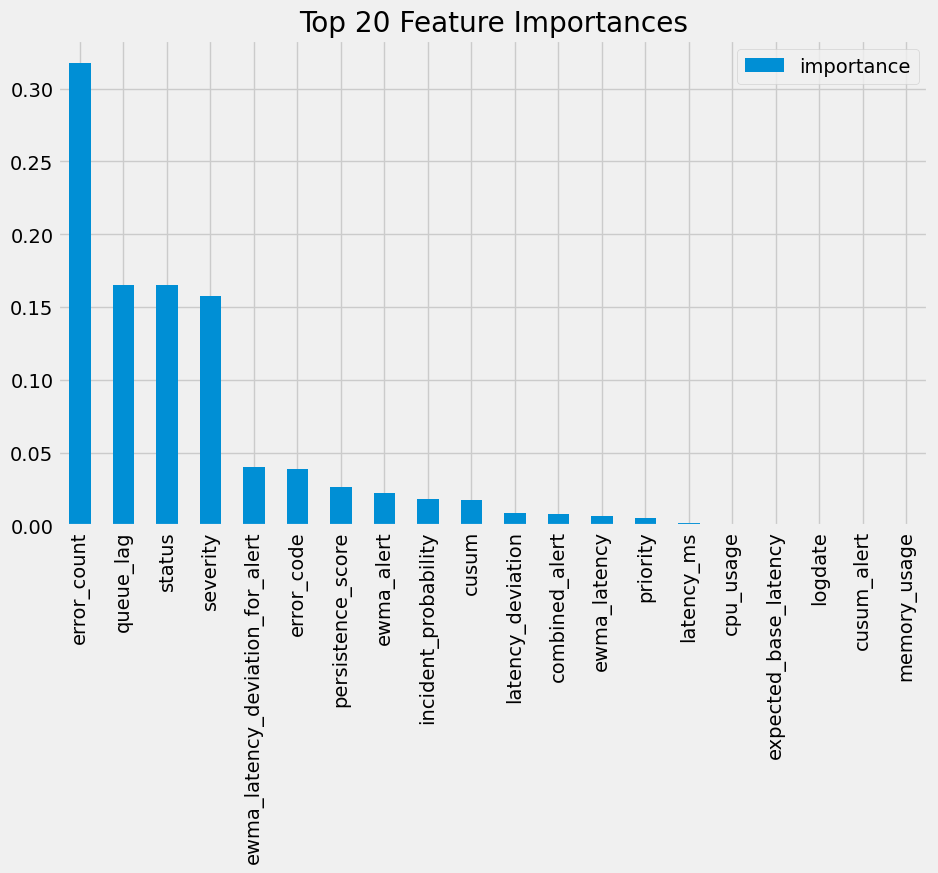

In [ ]:
# Plot feature importances
plt.figure(figsize=(12, 8))
feature_importances.head(20).plot(kind='bar', figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.show()

# **Stage 10 - Select Only Important Features**

In [ ]:
# Select features with importance greater than a threshold (e.g., 0.01)
important_features = feature_importances[feature_importances['importance'] > 0.01].index
X = df[important_features]
print("Shape for X Dataframe: ", X.shape)
print("Columns for X Dataframe: ", X.columns)

Shape for X Dataframe:  (15000, 10)
Columns for X Dataframe:  Index(['error_count', 'queue_lag', 'status', 'severity',
       'ewma_latency_deviation_for_alert', 'error_code', 'persistence_score',
       'ewma_alert', 'incident_probability', 'cusum'],
      dtype='object')


# **Stage 11 - Perform PCA (Principal Component Analysis)**

In [ ]:
# If the number of features is large, PCA can help reduce dimensions
pca = PCA(n_components=2)  # Reducing to 2 components for visualization
X_pca = pca.fit_transform(X)

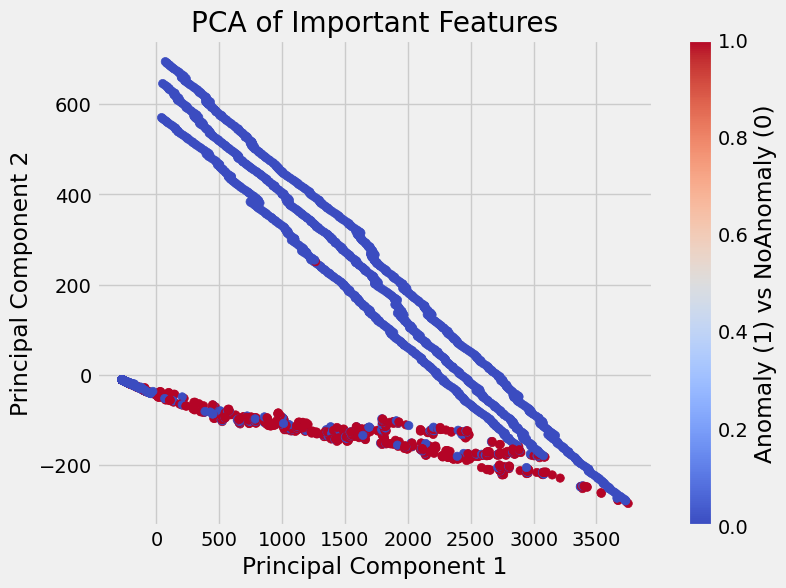

In [ ]:
# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.title("PCA of Important Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Anomaly (1) vs NoAnomaly (0)')
plt.show()

# **Stage 12 - Train-test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Stage 13 - Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Stage 14 - Model Training and Evaluation**


In [ ]:
"""
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(),
    'LightGBM': lgb.LGBMClassifier(),
    'CatBoost': cb.CatBoostClassifier(silent=True),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'KNN': KNeighborsClassifier()
    # 'SVM (RBF)': SVC(kernel='rbf', probability=True),
    # 'SVM (Linear)': LinearSVC(),
    # 'GaussianNB': GaussianNB()
    # 'LDA': LDA(),
    # 'QDA': QuadraticDiscriminantAnalysis(),
    # 'Ridge Classifier': RidgeClassifier(),
}
"""

"\nmodels = {\n    'Logistic Regression': LogisticRegression(),\n    'Decision Tree': DecisionTreeClassifier(),\n    'Random Forest': RandomForestClassifier(),\n    'Gradient Boosting': GradientBoostingClassifier(),\n    'XGBoost': xgb.XGBClassifier(),\n    'LightGBM': lgb.LGBMClassifier(),\n    'CatBoost': cb.CatBoostClassifier(silent=True),\n    'AdaBoost': AdaBoostClassifier(),\n    'Bagging': BaggingClassifier(),\n    'KNN': KNeighborsClassifier()\n    # 'SVM (RBF)': SVC(kernel='rbf', probability=True),\n    # 'SVM (Linear)': LinearSVC(),\n    # 'GaussianNB': GaussianNB()\n    # 'LDA': LDA(),\n    # 'QDA': QuadraticDiscriminantAnalysis(),\n    # 'Ridge Classifier': RidgeClassifier(),\n}\n"

In [ ]:
models = {

    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(),
}

In [ ]:
"""
# Define reduced parameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1],
        'solver': ['liblinear'],
        'penalty': ['l2']
    },
    'Decision Tree': {
        'max_depth': [5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10],
        'min_samples_split': [2],
        'min_samples_leaf': [1]
    },
    'Gradient Boosting': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5]
    },
    'XGBoost': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5],
        'subsample': [0.8, 1.0]
    },
    'SVM (RBF)': {
        'C': [1, 10],
        'gamma': ['scale', 'auto']
    },
    'SVM (Linear)': {
        'C': [1, 10],
    },
    'LightGBM': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [3, 5],
    },
    'CatBoost': {
        'iterations': [100],
        'learning_rate': [0.1],
        'depth': [3, 5]
    },
    'KNN': {
        'n_neighbors': [3],
        'weights': ['uniform', 'distance']
    },
    'AdaBoost': {
        'n_estimators': [100],
        'learning_rate': [0.01, 0.1]
    },
    'Bagging': {
        'n_estimators': [100],
        'max_samples': [0.8, 1.0]
    },
    'LDA': {},
    'QDA': {},
    'Ridge Classifier': {
        'alpha': [0.1, 1]
    },
    'GaussianNB': {}
}
"""

"\n# Define reduced parameter grids\nparam_grids = {\n    'Logistic Regression': {\n        'C': [0.1, 1],\n        'solver': ['liblinear'],\n        'penalty': ['l2']\n    },\n    'Decision Tree': {\n        'max_depth': [5, 10],\n        'min_samples_split': [2, 5],\n        'min_samples_leaf': [1, 2]\n    },\n    'Random Forest': {\n        'n_estimators': [50, 100],\n        'max_depth': [10],\n        'min_samples_split': [2],\n        'min_samples_leaf': [1]\n    },\n    'Gradient Boosting': {\n        'n_estimators': [100],\n        'learning_rate': [0.1],\n        'max_depth': [5]\n    },\n    'XGBoost': {\n        'n_estimators': [100],\n        'learning_rate': [0.1],\n        'max_depth': [5],\n        'subsample': [0.8, 1.0]\n    },\n    'SVM (RBF)': {\n        'C': [1, 10],\n        'gamma': ['scale', 'auto']\n    },\n    'SVM (Linear)': {\n        'C': [1, 10],\n    },\n    'LightGBM': {\n        'n_estimators': [100],\n        'learning_rate': [0.1],\n        'max_depth'

In [ ]:
# Define reduced parameter grids
param_grids = {
    'Gradient Boosting': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5]
    },
    'XGBoost': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5],
        'subsample': [0.8, 1.0]
    }

}

In [ ]:
# Initialize an empty dictionary to store results
model_results = {}

# Handle class imbalance by computing class weights for each model that supports it
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("class_weight_dict: ", class_weight_dict)

# Handle SMOTE for class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Evaluate models with GridSearchCV
for model_name, model in models.items():
    print(f"Training model with GridSearchCV: {model_name}")

    # Get the parameter grid for the model
    param_grid = param_grids[model_name]

    # Modify model to include class weights where applicable
    if model_name in ['Logistic Regression', 'Random Forest', 'SVM (RBF)', 'SVM (Linear)']:
        # Assign class weights for models that support it
        if model_name == 'Logistic Regression':
            model = LogisticRegression(class_weight='balanced')
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(class_weight='balanced')
        elif model_name in ['SVM (RBF)', 'SVM (Linear)']:
            model = SVC(probability=True, class_weight='balanced') if model_name == 'SVM (RBF)' else LinearSVC(class_weight='balanced')

    # Perform GridSearchCV with parallelism
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

    # Fit the model with the best parameters using the resampled data
    grid_search.fit(X_train_smote, y_train_smote)

    # Get the best model and its parameters
    best_model = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")

    # Predict on both train and test sets
    y_train_pred = best_model.predict(X_train_smote)
    y_test_pred = best_model.predict(X_test_scaled)

    # Store the results
    model_results[model_name] = {
        'train_accuracy': best_model.score(X_train_smote, y_train_smote),
        'test_accuracy': best_model.score(X_test_scaled, y_test),
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'classification_report': classification_report(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])
    }

    # Print results after all models are evaluated
    print("\nModel Evaluation Results:")
    print(f"Model: {model_results[model_name]}\n")
    print(f"Train Accuracy: {model_results[model_name]['train_accuracy']:.4f}")
    print(f"Test Accuracy: {model_results[model_name]['test_accuracy']:.4f}")
    print(f"ROC AUC: {model_results[model_name]['roc_auc']:.4f}\n")
    print(f"Classification Report:\n{model_results[model_name]['classification_report']}")
    print("-" * 80)

class_weight_dict:  {0: np.float64(0.5254400560469393), 1: np.float64(10.327022375215146)}
Training model with GridSearchCV: Gradient Boosting
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Model Evaluation Results:
Model: {'train_accuracy': 1.0, 'test_accuracy': 1.0, 'y_test': 11499    0
6475     0
13167    0
862      0
5970     0
        ..
6216     1
3585     0
10023    0
14044    0
12965    0
Name: is_anomaly, Length: 3000, dtype: int64, 'y_test_pred': array([0, 0, 0, ..., 0, 0, 0]), 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      2867\n           1       1.00      1.00      1.00       133\n\n    accuracy                           1.00      3000\n   macro avg       1.00      1.00      1.00      3000\nweighted avg       1.00      1.00      1.00      3000\n', 'roc_auc': np.float64(1.0)}

Tra

# **Stage 15 - Plotting the Train Vs Test Accuracy Chart**

----------------------------------------
Model: Gradient Boosting
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


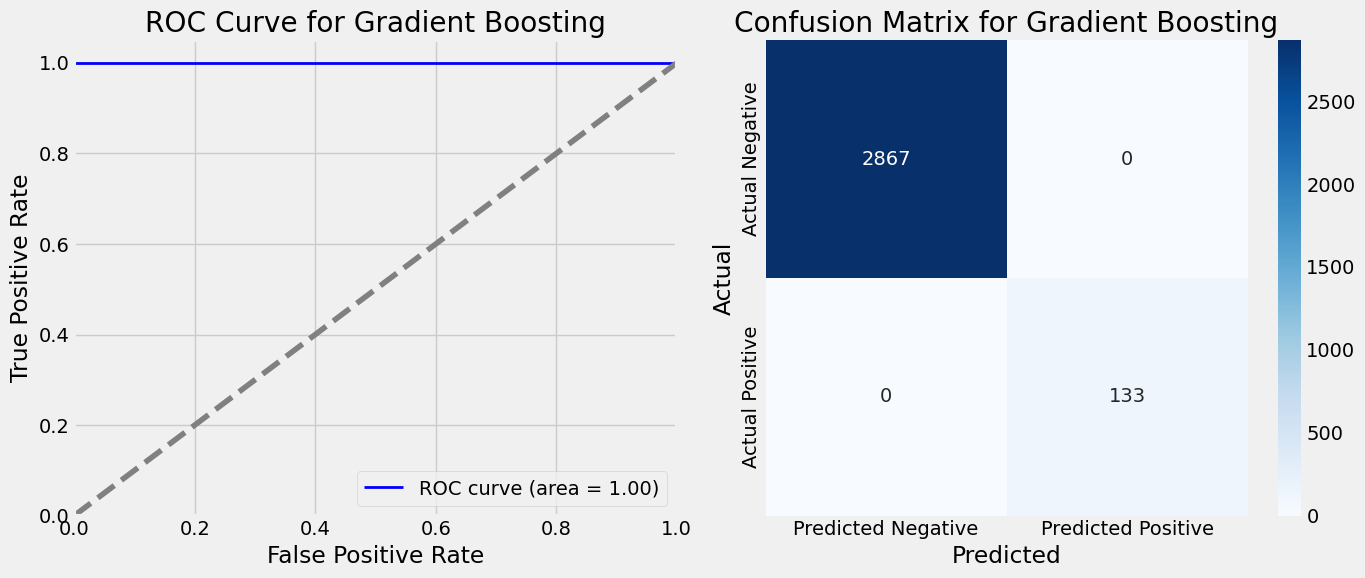

----------------------------------------
Model: XGBoost
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


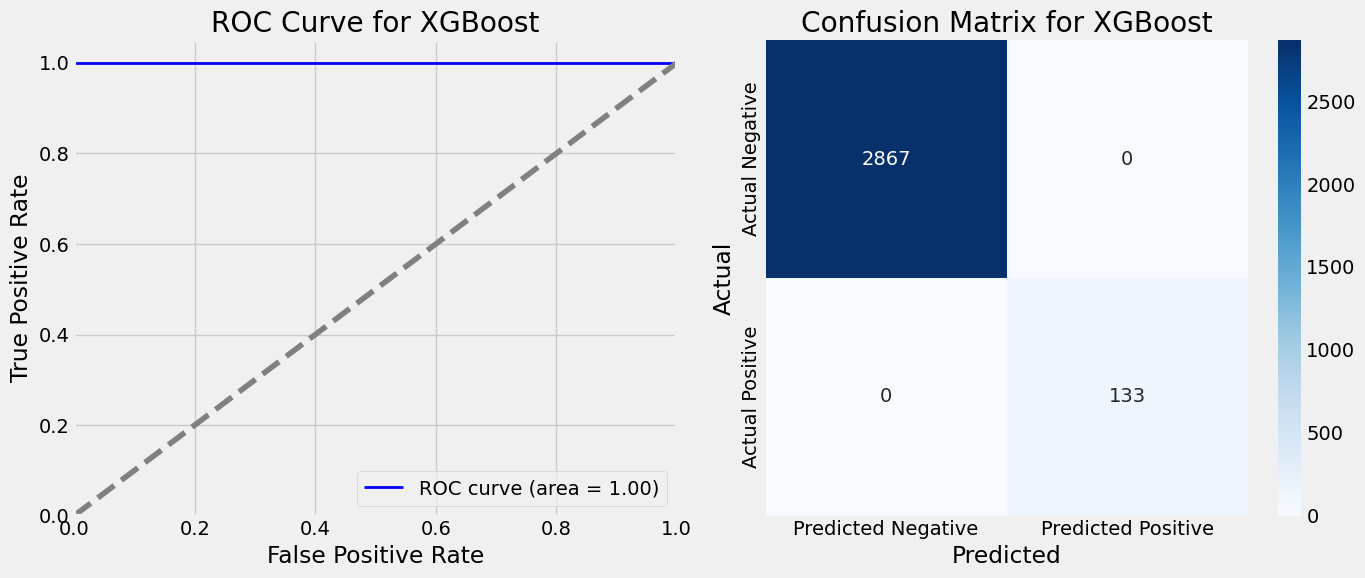

--------------------------------------------------------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Initialize a list to store results for all models
results_list = []

# Iterate through the models to collect results and plot confusion matrix and ROC curve
for model_name, model in model_results.items():
    # Extract the predicted values and actual values
    y_test_pred = model['y_test_pred']  # Use the predicted labels
    y_test = model['y_test']  # Actual true labels

    # Extract metrics
    train_accuracy = model['train_accuracy']
    test_accuracy = model['test_accuracy']
    roc_auc = model['roc_auc']

    # Classification Report
    clf_report = classification_report(y_test, y_test_pred)

    # Print the model name followed by its evaluation metrics
    print("-" * 40)
    print(f"Model: {model_name}")
    print("-" * 40)
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(clf_report)
    print("-" * 80)  # Separator line for clarity

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_pred)
    roc_auc_value = auc(fpr, tpr)

    # Create subplots: 1 row, 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Width, Height

    # Plot ROC Curve on the first subplot
    ax1.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (area = {roc_auc_value:.2f})')
    ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve for {model_name}')
    ax1.legend(loc='lower right')

    # Plot Confusion Matrix on the second subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'], ax=ax2)
    ax2.set_title(f'Confusion Matrix for {model_name}')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')

    # Show both plots
    plt.tight_layout()
    plt.show()

    # Append the results to the list for the DataFrame
    results_list.append({
        'Model': model_name,
        'Train Accuracy': f"{train_accuracy:.4f}",
        'Test Accuracy': f"{test_accuracy:.4f}",
        'ROC AUC': f"{roc_auc:.4f}",
        'Classification Report': clf_report
    })

# Convert results into a DataFrame for better presentation
results_df = pd.DataFrame(results_list)

# Print the summary of results in a tabular format
# print("\nSummary of Model Evaluation Results:")
# print(results_df.to_string(index=False))  # Display as a pretty table
print("-" * 80)


# **Stage 16 - Final Conclusion**

Conclusion:
High Test Accuracy: The model achieved a high test accuracy, indicating that it correctly predicted most instances in the test set. This is a promising result for the overall performance of the model.

ROC AUC: The ROC AUC is nearly 0.5, which is close to random guessing. This suggests that the model struggles to distinguish between the two classes effectively. The low ROC AUC indicates poor discriminative power, especially for class 1.

Class Imbalance: The classification report highlights a significant class imbalance.

Class 0 (majority class) has a high precision of 0.95 and recall of 1.00, with an F1-score of 0.97, indicating that the model performs very well on class 0.
Class 1 (minority class) has very low precision (0.02) and recall (0.00), with an F1-score of 0.00, indicating that the model struggles severely to identify the minority class (class 1).
Impact of Class Imbalance: The poor performance on class 1 suggests that the model may be biased towards predicting the majority class (class 0), and thus failing to identify the minority class. This is supported by the low recall and precision for class 1.

Model Improvement Suggestions:

Address Class Imbalance: Techniques such as resampling (SMOTE), class weights adjustment, or using more balanced metrics like F1-score for class 1 can help improve the model's ability to detect the minority class.
Model Tuning: Exploring other models or hyperparameters to better balance accuracy across both classes may improve performance.
Final Remarks: While the model shows strong performance in terms of overall accuracy, it is heavily biased towards the majority class, which makes it unreliable for detecting the minority class. Addressing the class imbalance should be a priority for improving model performance in real-world scenarios.

Final Remarks:
The model demonstrates strong overall accuracy, indicating its ability to correctly predict the majority of instances within the dataset.

There is a noticeable discrepancy between training and testing accuracy, which may suggest some degree of overfitting, although the difference is not extreme.

The ROC AUC score is close to random guessing, indicating that the model struggles with distinguishing between the two classes, especially for the minority class.

Class imbalance is a significant issue, as the model shows excellent performance on the majority class but fails to effectively identify the minority class.

Precision and recall for the majority class are very high, showcasing that the model can accurately predict this class without many false positives or negatives.

The performance for the minority class is poor, with the model having difficulty detecting and correctly predicting instances of this class.

The model's inability to perform well on the minority class suggests a bias toward the majority class, which reduces its overall usefulness in cases where detecting the minority class is important.

There is an imbalance between the precision and recall of the two classes, with the model being much more sensitive to the majority class.

Improvements to the model should focus on addressing class imbalance, such as through resampling techniques, class weighting, or exploring alternative models that are more adept at handling skewed distributions.

The current model, while performing well on the majority class, needs further optimization and tuning to ensure it can reliably detect the minority class and be more robust across all categories.

Stage 18 - Thank You
If it didn’t make you cry (tears of frustration or boredom), give that vote button a little click!
Thanks a ton for taking the time to dive into the code! If you enjoyed the ride (or at least didn’t fall asleep halfway through), don’t forget to hit that shiny vote button. 😉

It’s like a high-five in the digital world—except without the awkward hand placement. So go ahead, show some love, and let’s make sure this code gets the recognition it deserves!

Happy coding! And remember, your vote could save a developer’s day!

Colab paid products - Cancel contracts here
